In [17]:
from moneyball_logic import *
import pandas as pd

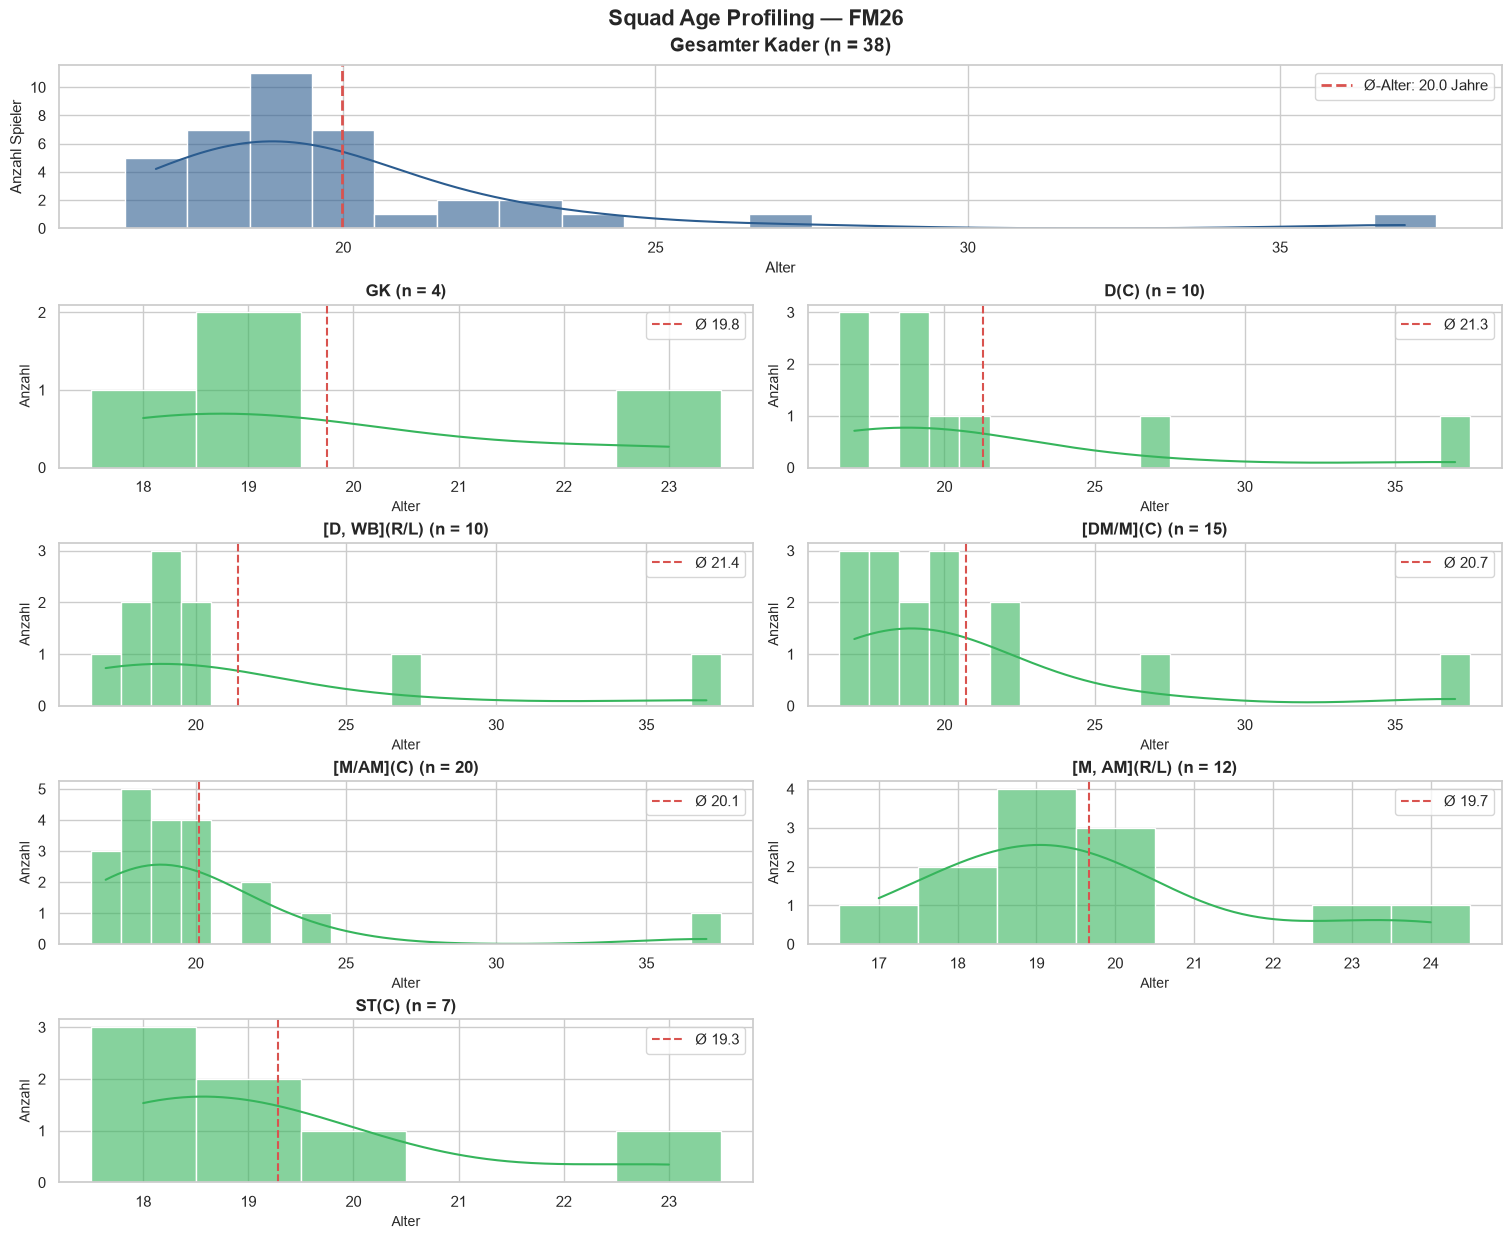

In [18]:
# Daten ohne Filter laden
df_squad = load_data("data_1860_own_team/2025_mos_II.csv")

# Grafik generieren
fig = plot_age_distribution_squad(df_squad)

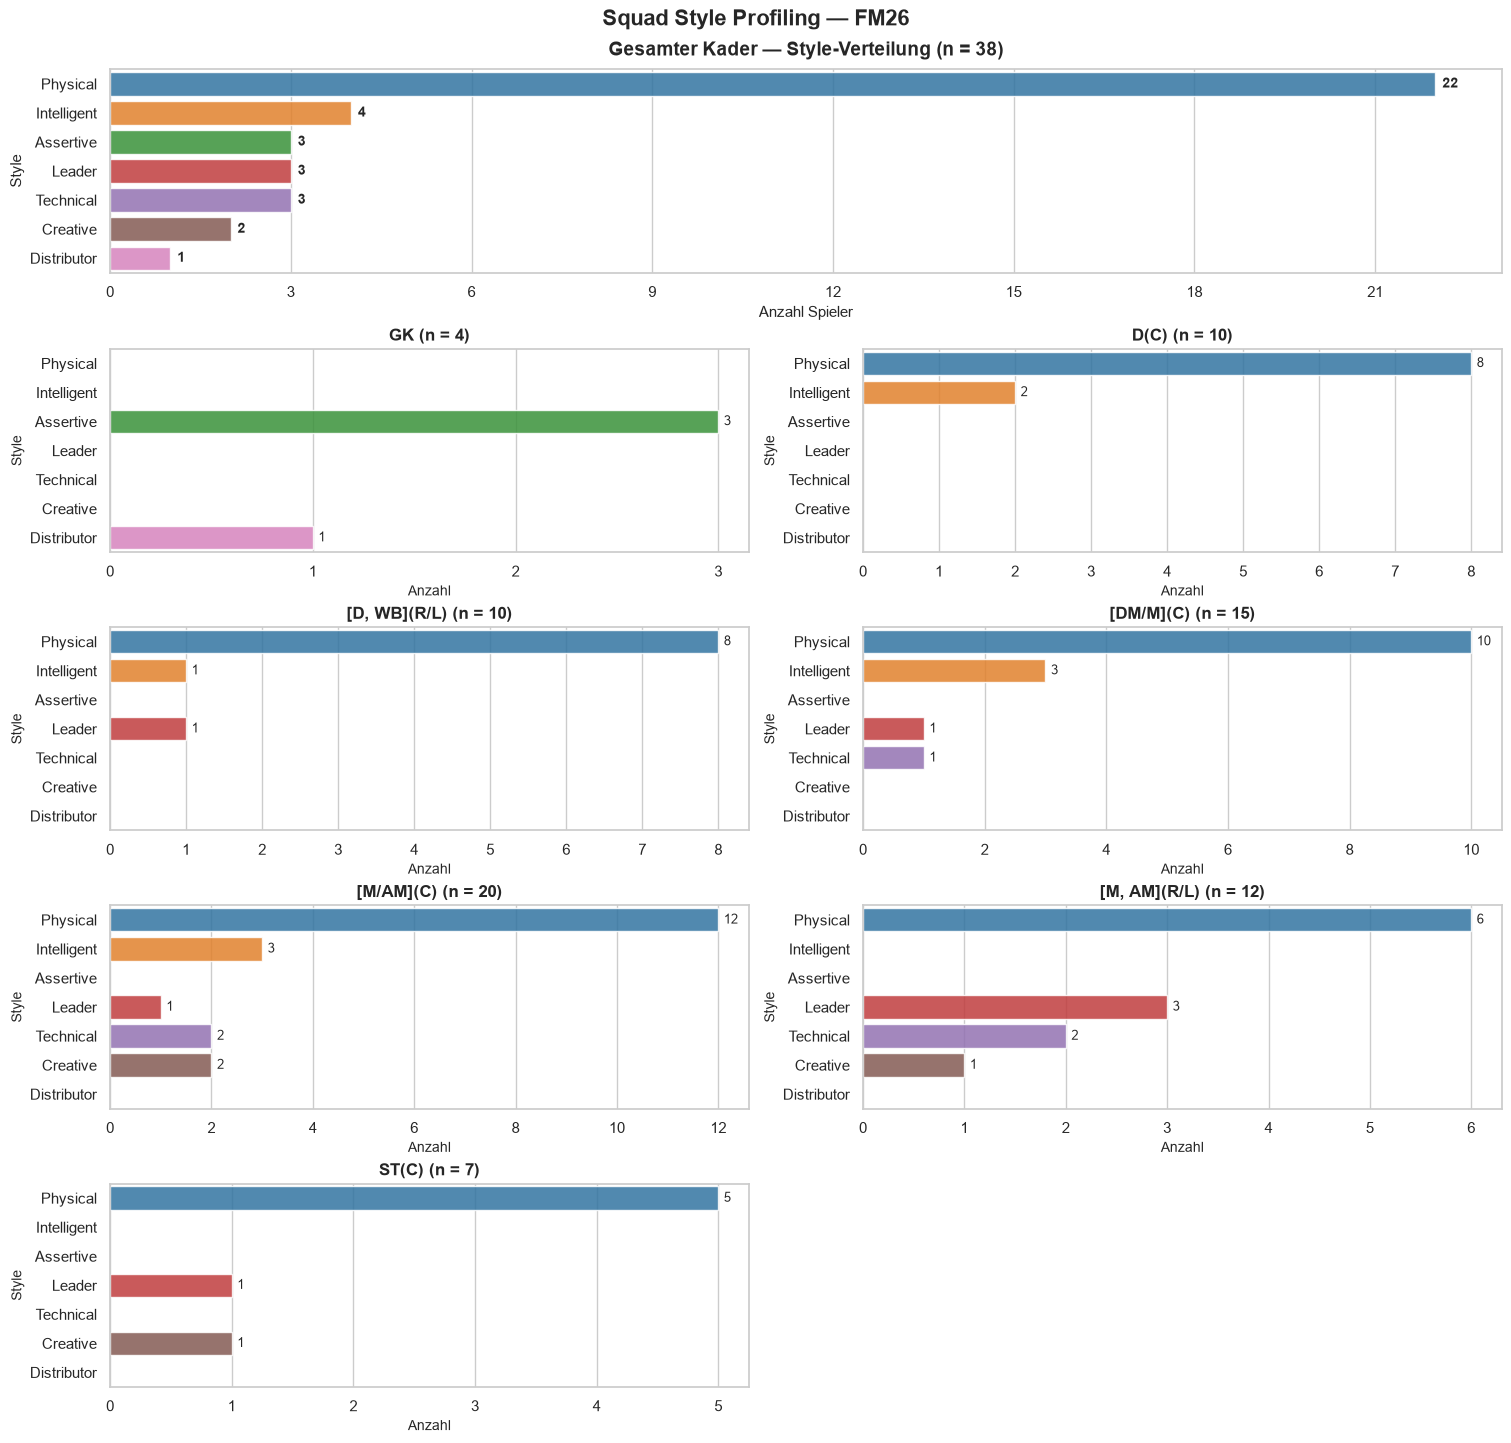

In [19]:
# Style-Verteilung grafisch darstellen
fig_style = plot_style_distribution_squad(df_squad)

# Player Profiling

In [20]:
import yaml
import matplotlib.pyplot as plt

from moneyball_logic import (
    load_data,
    prepare_dataframe,
    filter_players_by_position,
    calculate_position_benchmarks,
    apply_league_normalization,
    plot_player_vs_benchmark_spider,
)

# 1. Konfiguration laden & Parameter definieren
MIN_MINUTES_PLAYED = 450  # Set your minimum minutes threshold here

with open("config.yaml", "r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

league_mult_cfg = config.get("general", {}).get("league_multipliers", {})
TOP_LEAGUES_CONFIG = league_mult_cfg.get("top_leagues", [])
DEFAULT_LEAGUE_MULTIPLIER = 1.0
INVERSE_METRICS = ["Possession Lost per 90"]

id_columns = ["Player", "Position", "Division", "Club", "Nation", "Based In", "Style", "Minutes"]

# 2. Daten laden
file_path = "data_1860/2025_mos_5BL.csv"
file_path_own_team = "data_1860_own_team/2025_mos_II.csv"

df_raw = load_data(file_path)
df_own_raw = load_data(file_path_own_team)

# 3. Daten durch prepare_dataframe säubern & konvertieren
df_base = prepare_dataframe(df_raw, id_columns=id_columns)
df_own_base = prepare_dataframe(df_own_raw, id_columns=id_columns)

# 3. Apply Minimum Minutes Filter to squad
if "Minutes" in df_own_base.columns:
    df_own_base = df_own_base[df_own_base["Minutes"] >= MIN_MINUTES_PLAYED].copy()

# 2. Normalize ALL metrics strictly between 0.0 and 1.0 based on df_base
df_base, df_own_base = normalize_metrics_0_to_1(
    df_base=df_base, df_own_base=df_own_base, exclude_columns=id_columns
)



In [21]:
# 4. Analytics-Schritt: Top-20 Benchmarks ermitteln
pos_config = config["positions"]
benchmarks = calculate_position_benchmarks(
    df_comparison=df_base,
    pos_config=pos_config,
    top_leagues_config=TOP_LEAGUES_CONFIG,
    default_multiplier=DEFAULT_LEAGUE_MULTIPLIER,
    top_n=20,
    inverse_metrics=INVERSE_METRICS,
)

# 5. Analytics-Schritt: Eigenen Kader normalisieren
all_metrics = {m for cfg in pos_config.values() for m in cfg.get("metrics", [])}
df_own_norm = apply_league_normalization(
    df_own_base,
    list(all_metrics),
    TOP_LEAGUES_CONFIG,
    DEFAULT_LEAGUE_MULTIPLIER,
)

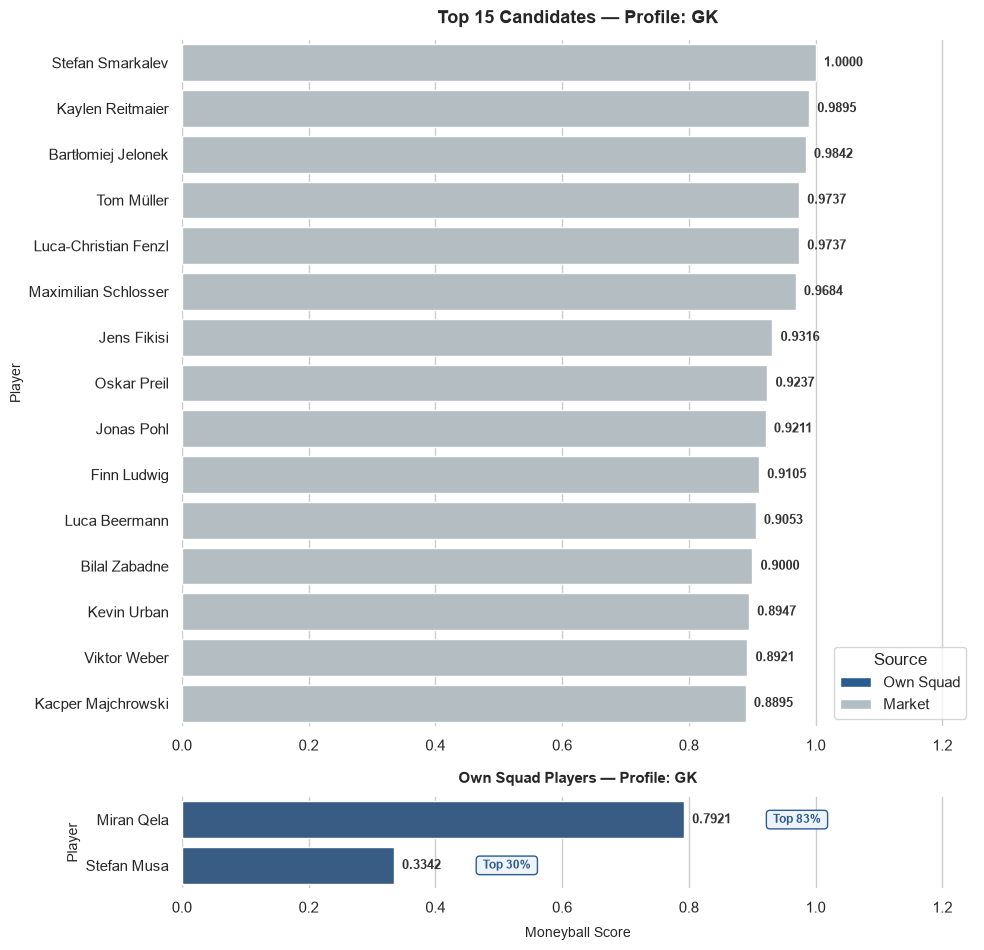

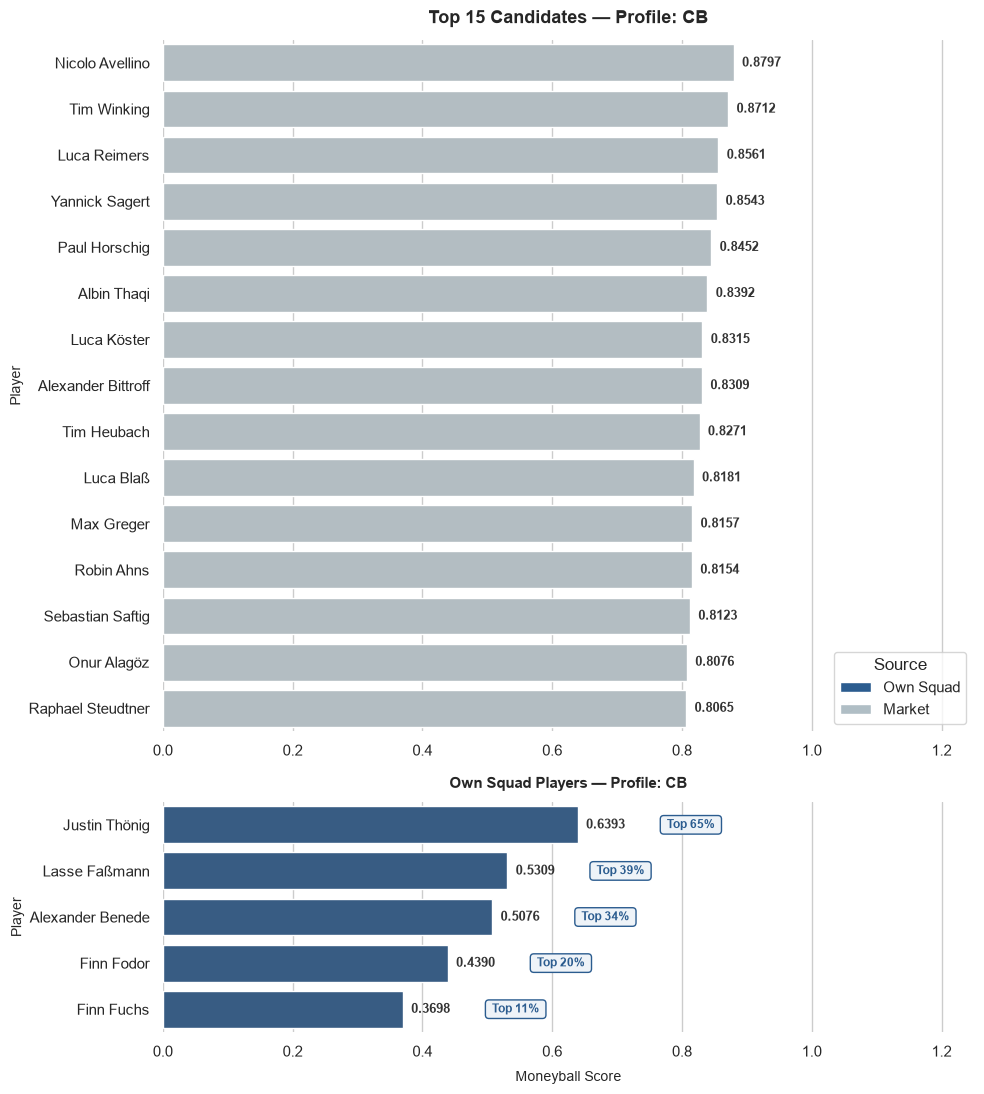

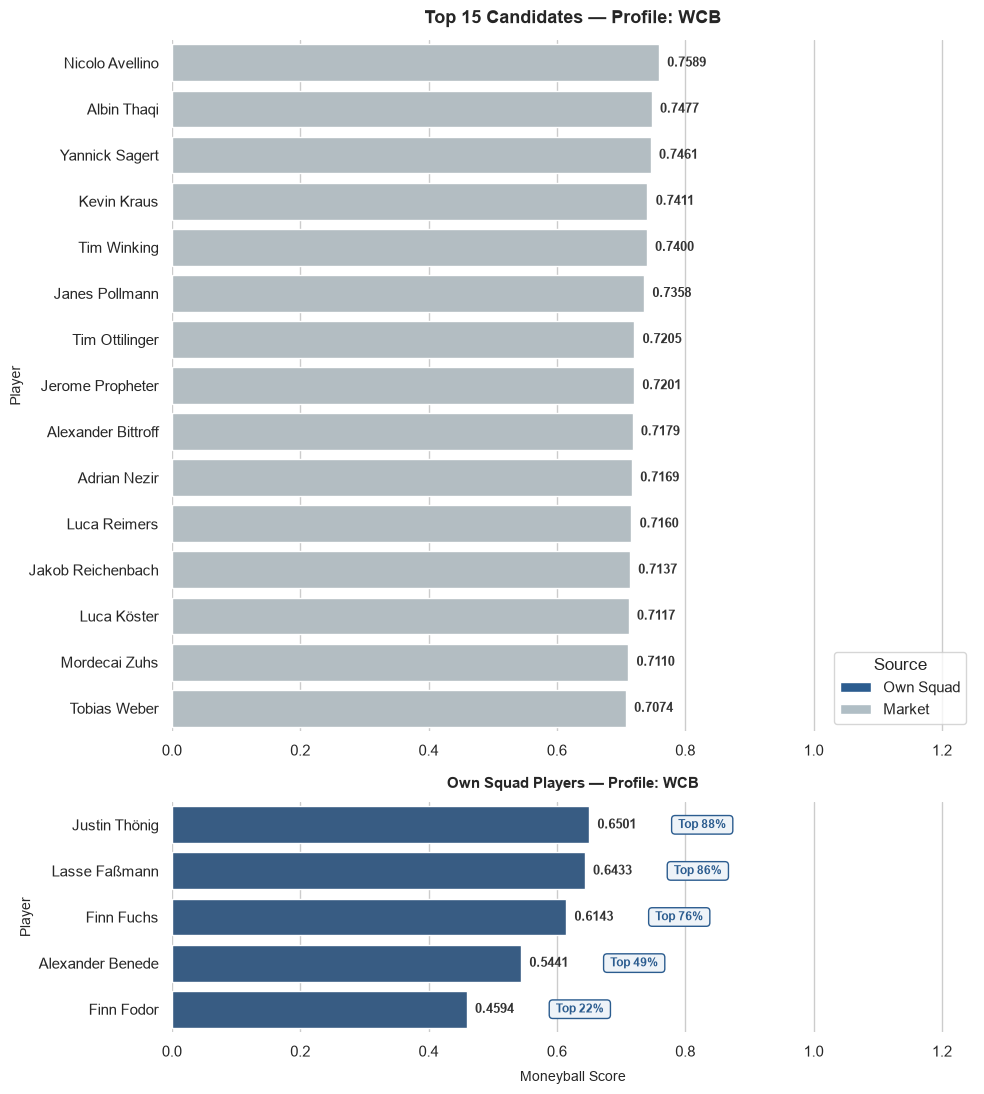

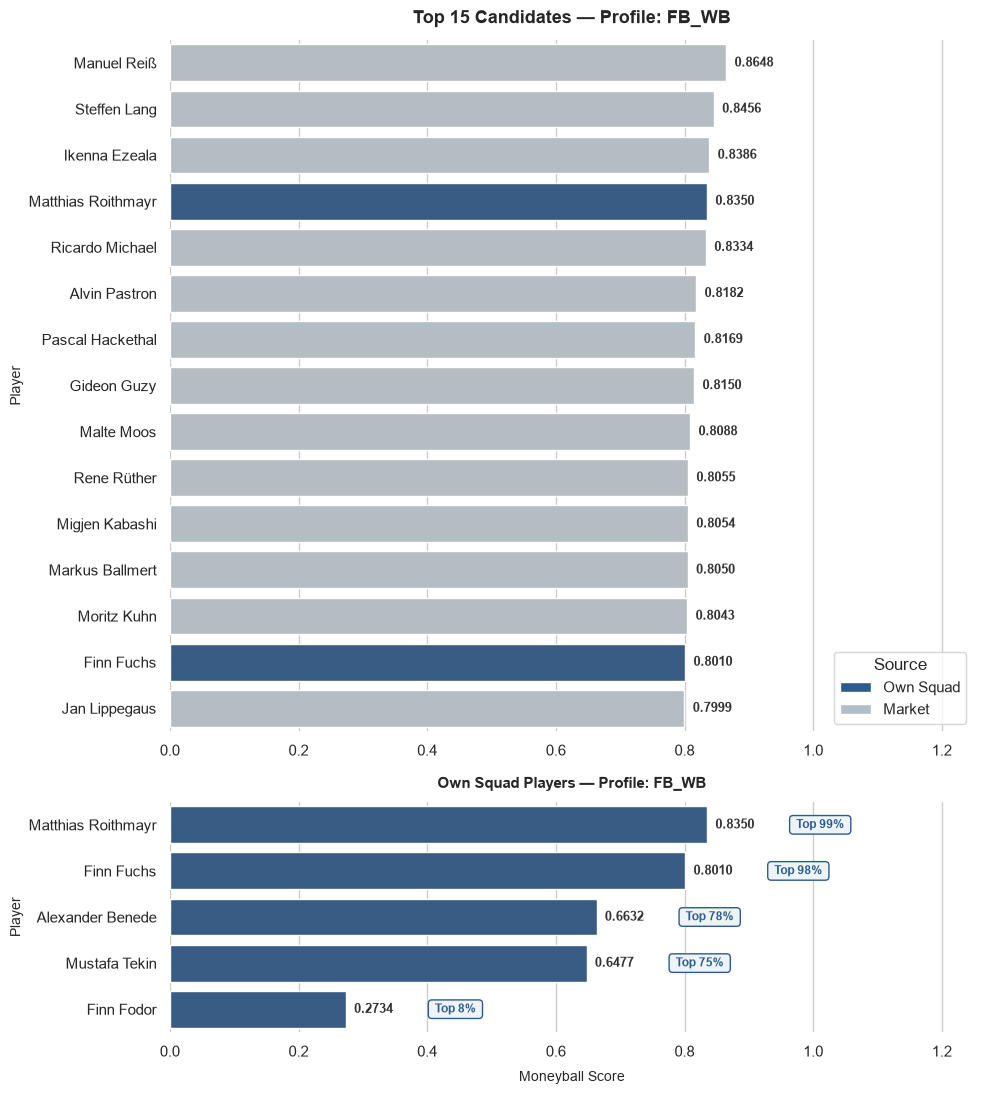

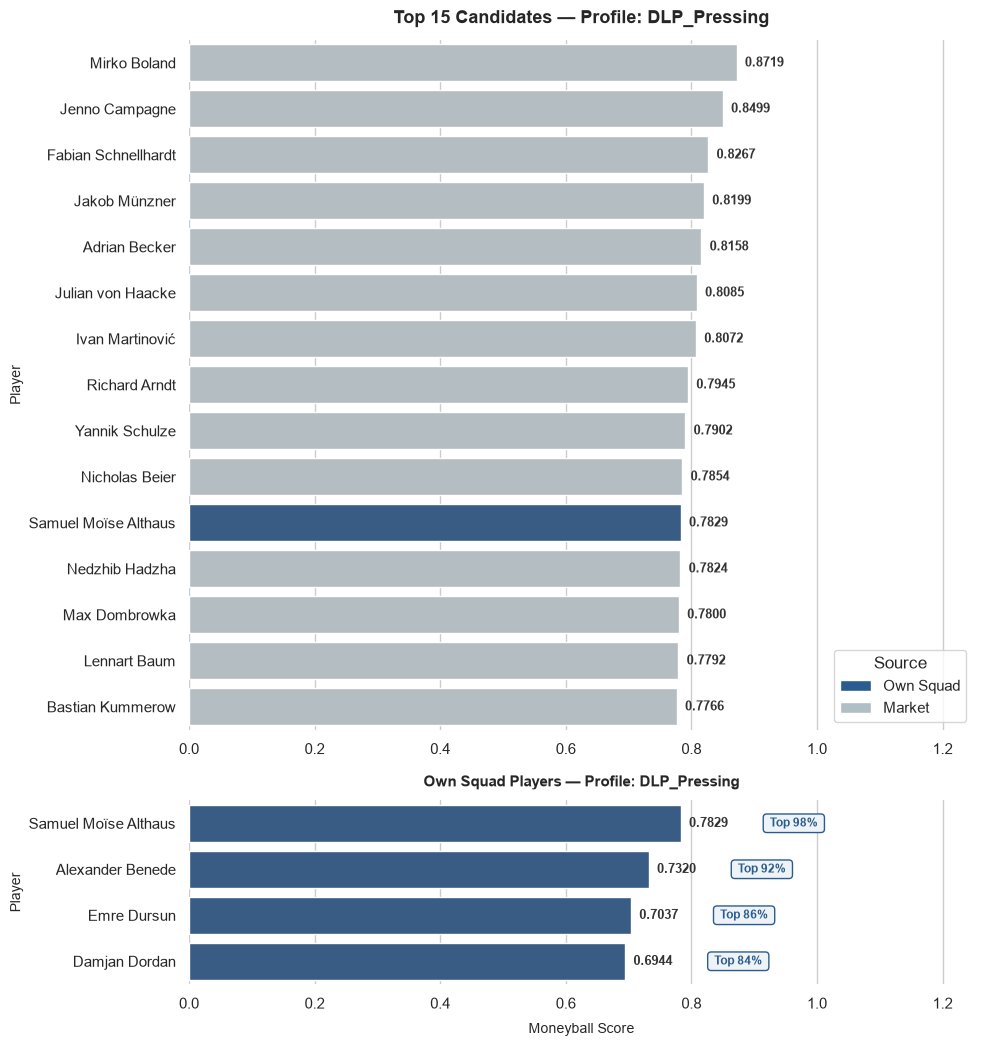

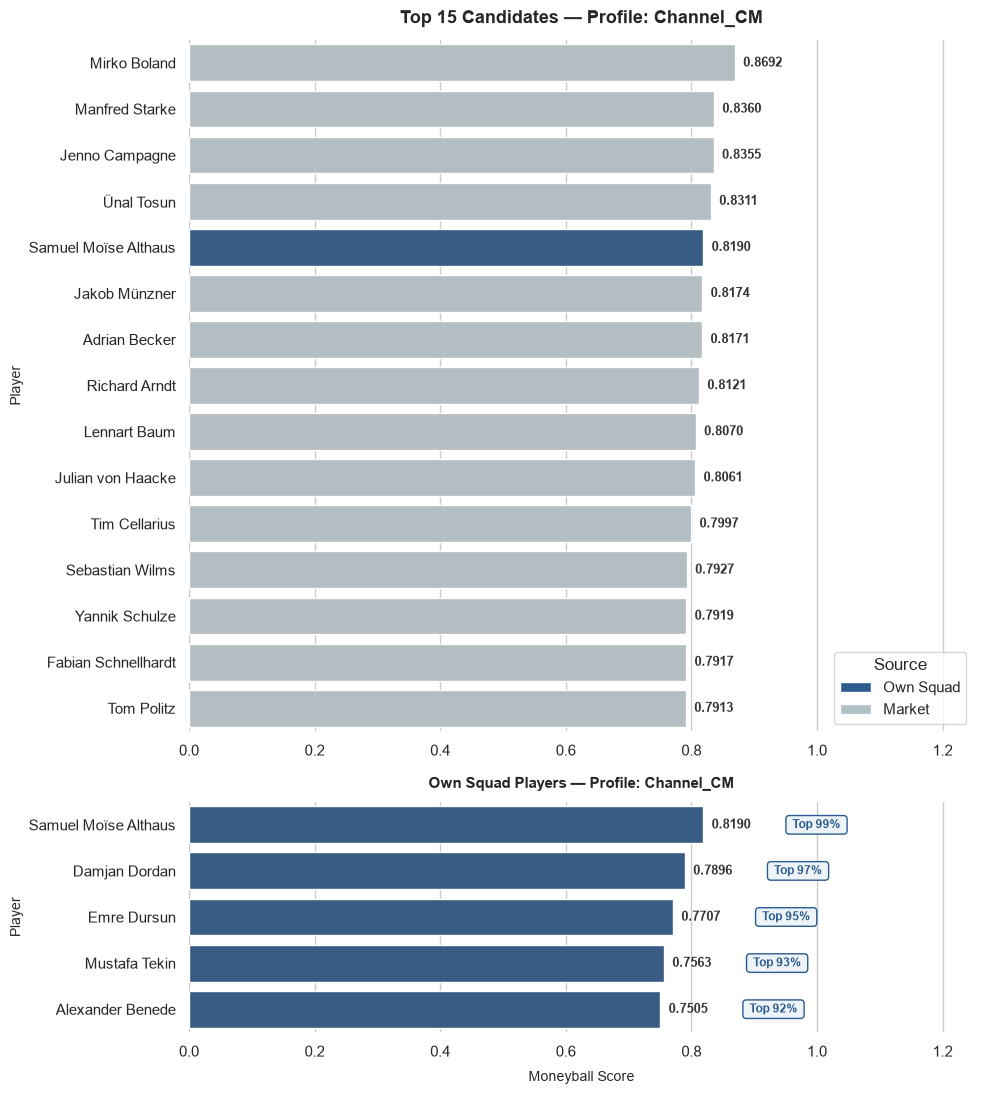

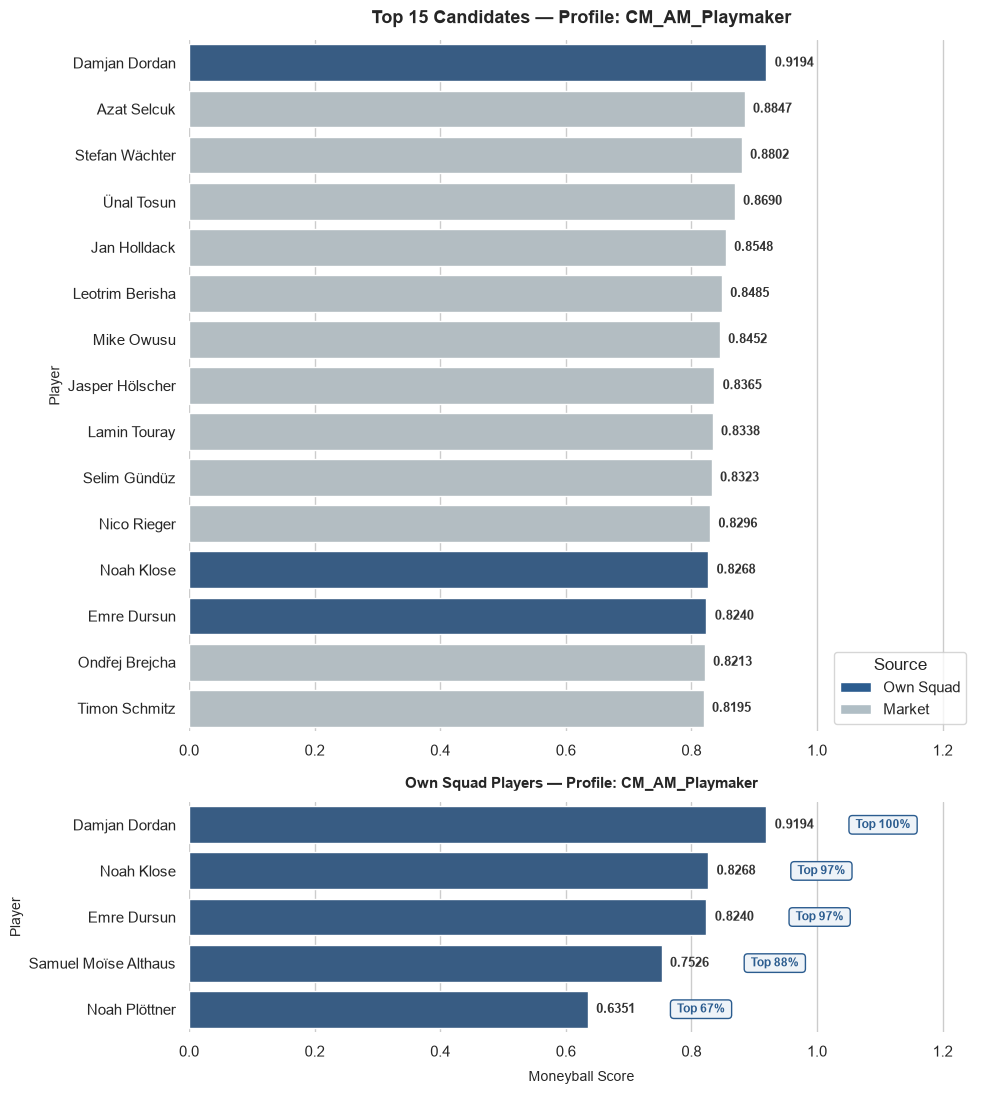

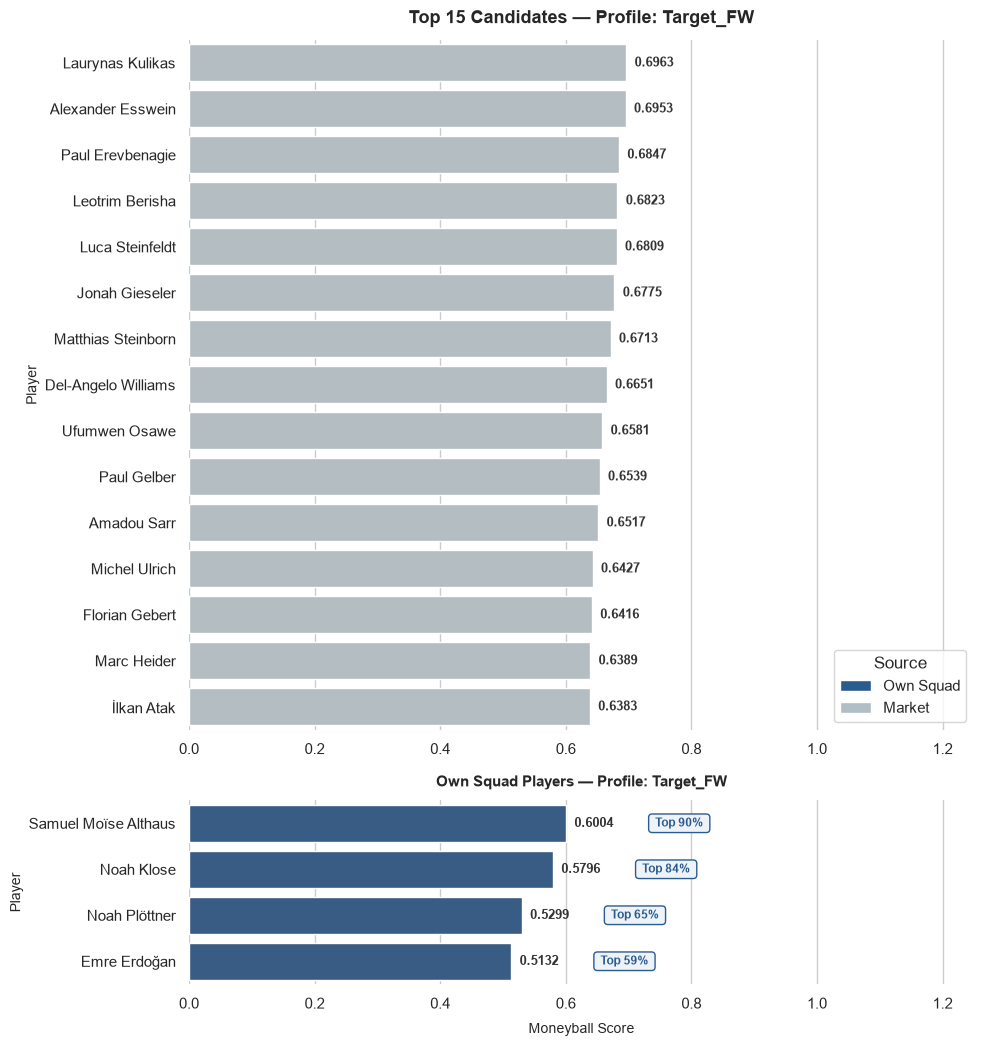

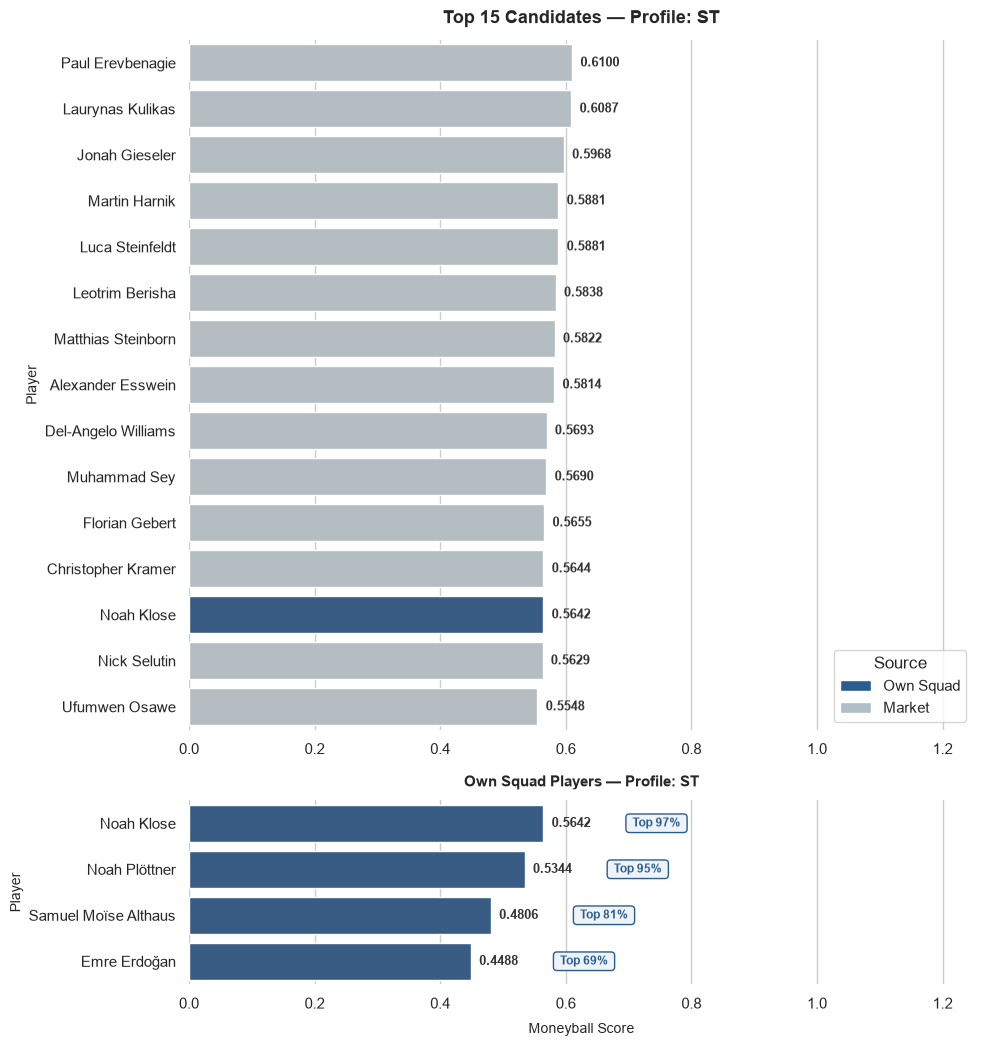

In [22]:
# Calculate profile scores for all players
shortlist_df = calculate_player_profile_scores(
    df_base=df_base, df_own_base=df_own_base, config=config
)

profile_figs = plot_top_players_per_profile_seaborn(
    shortlist_df=shortlist_df, config=config, top_n=15
)

=== Profil: GK (2 Spieler im Kader) ===


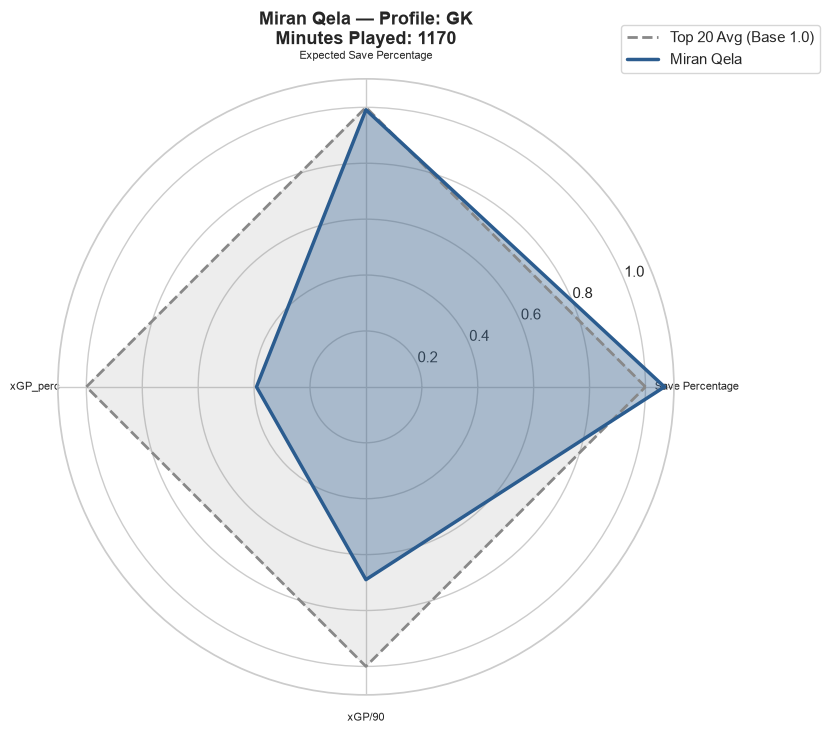

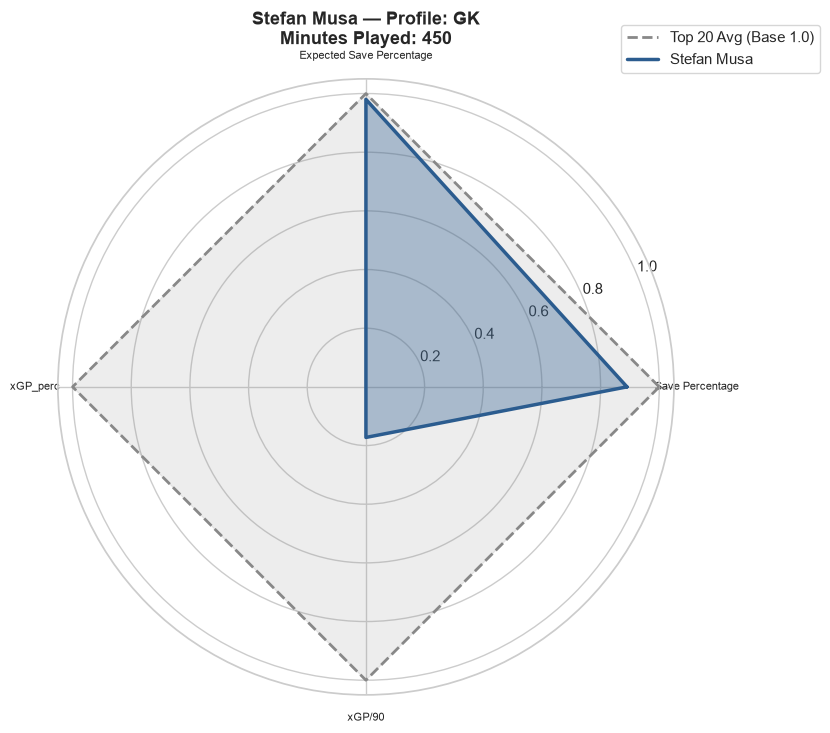

=== Profil: CB (5 Spieler im Kader) ===


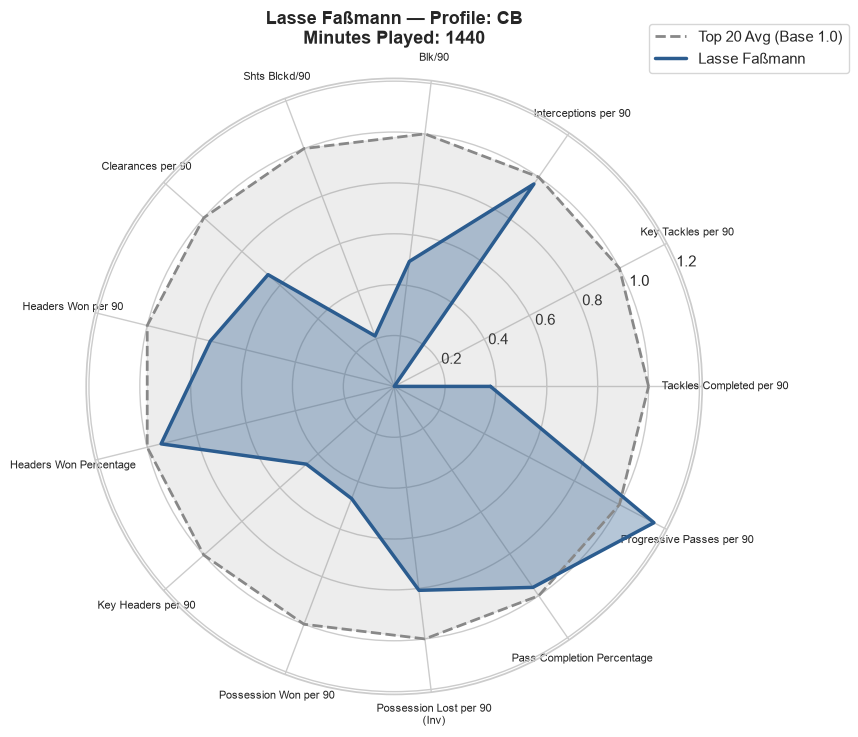

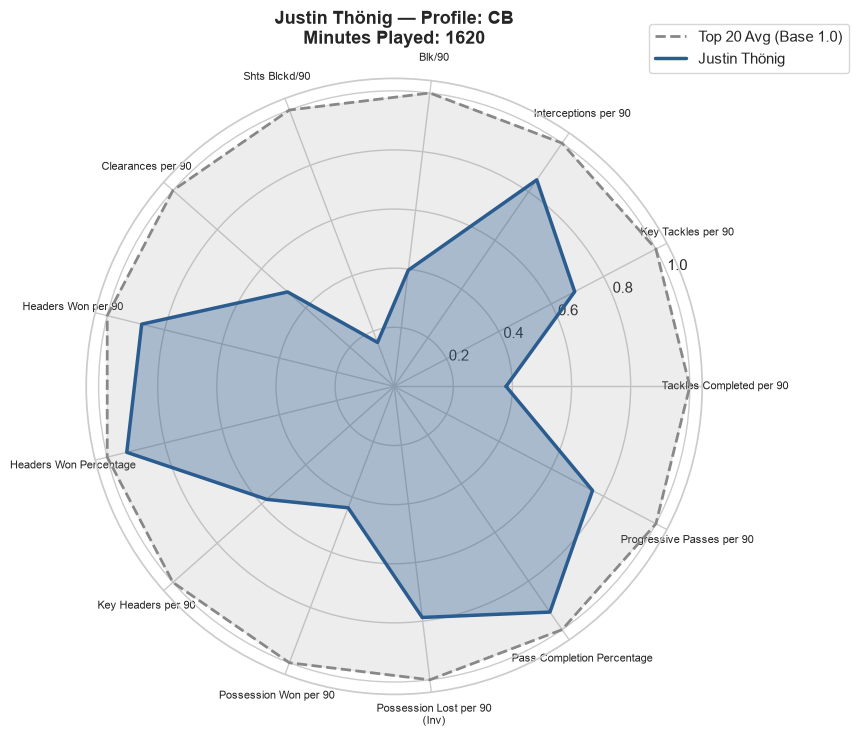

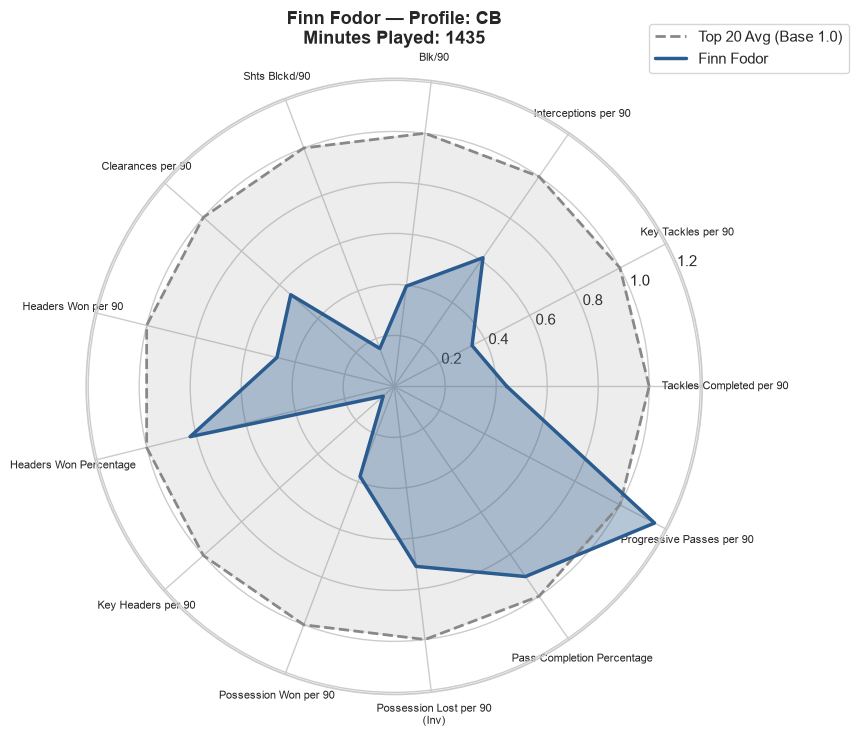

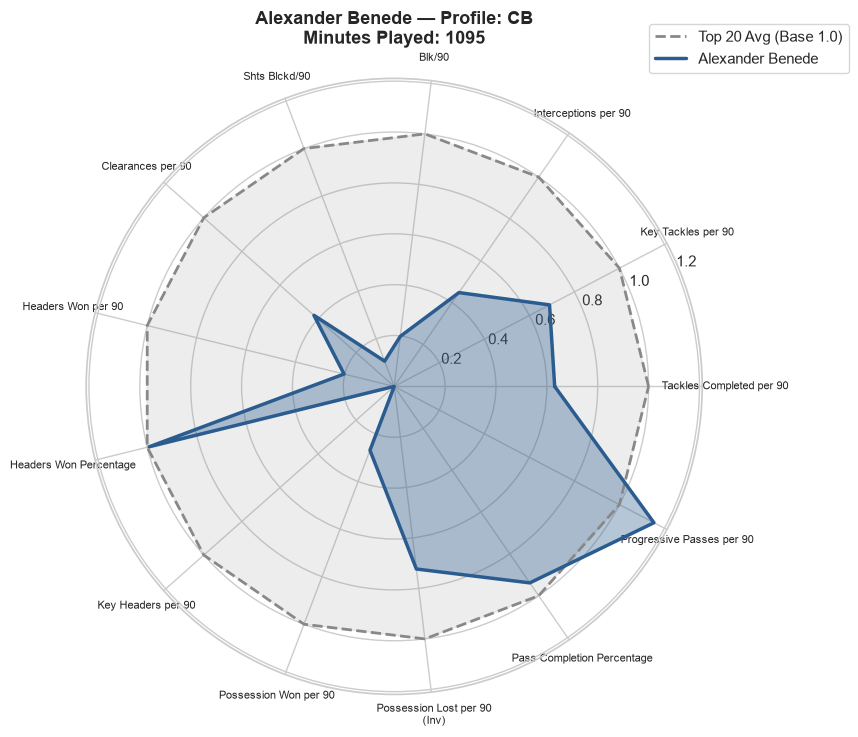

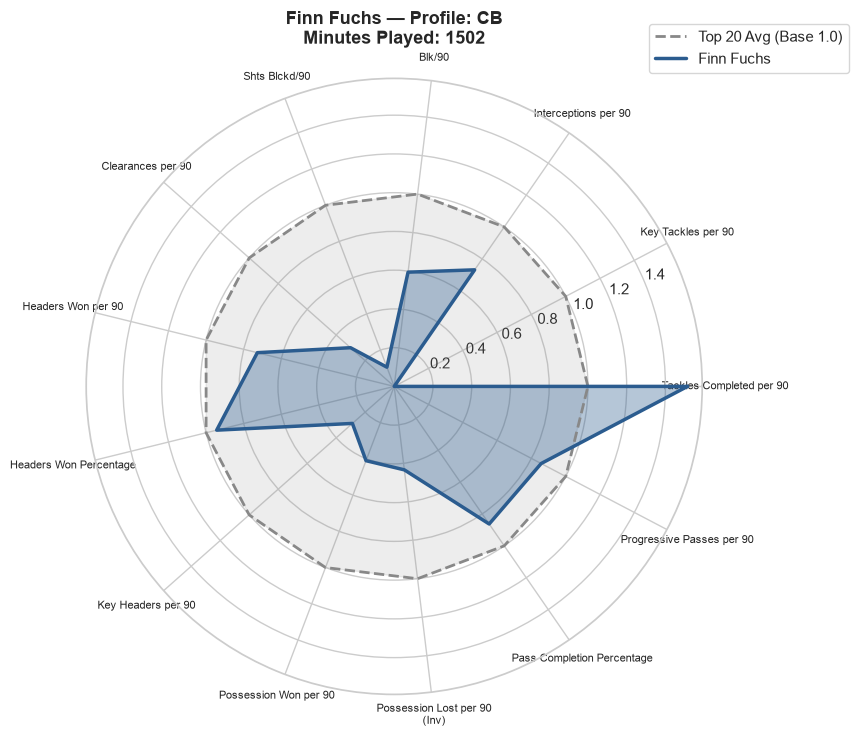

=== Profil: WCB (5 Spieler im Kader) ===


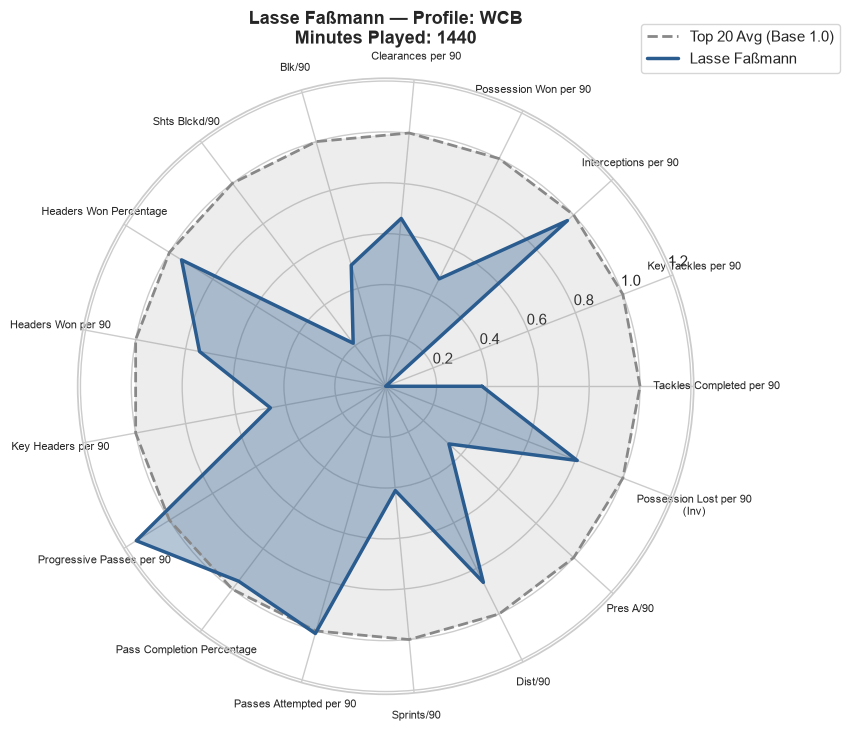

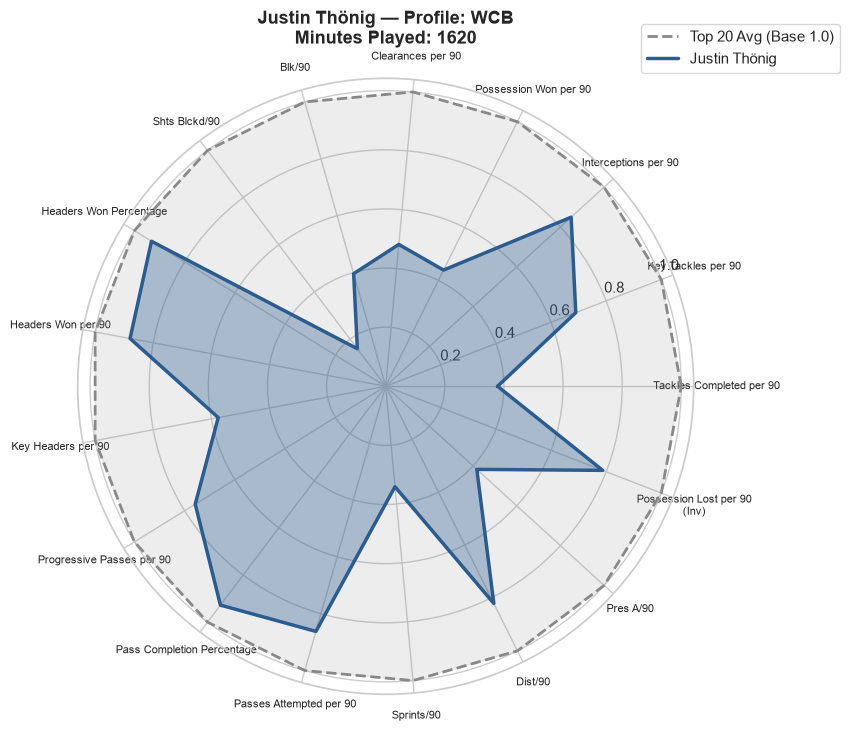

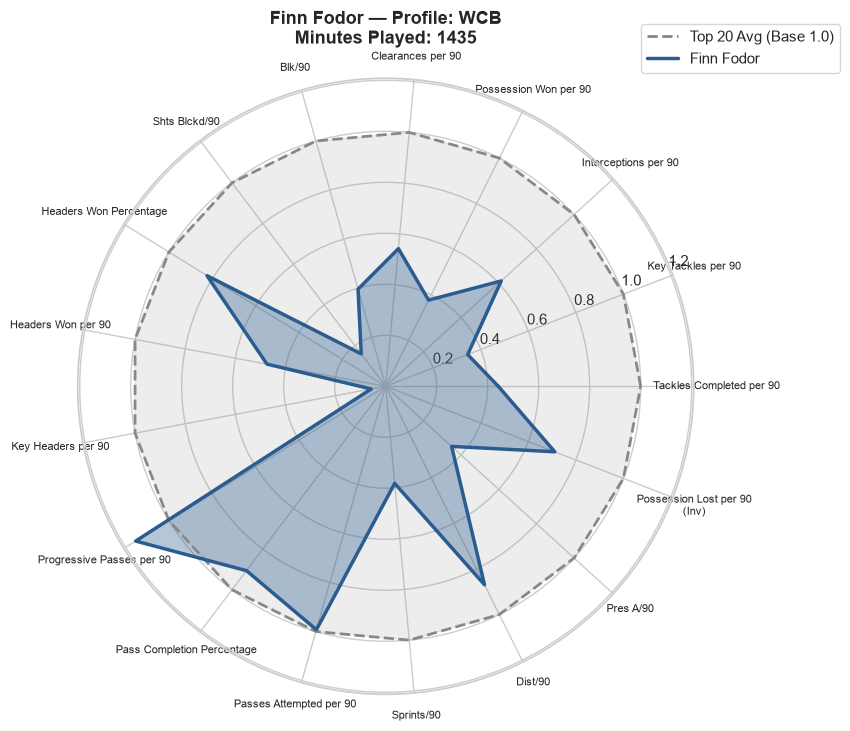

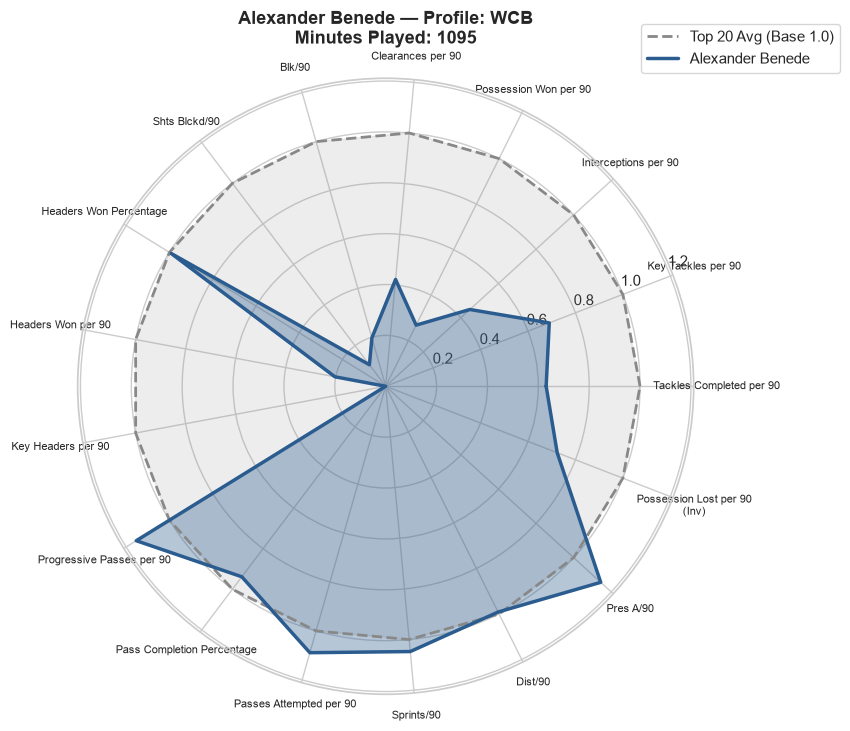

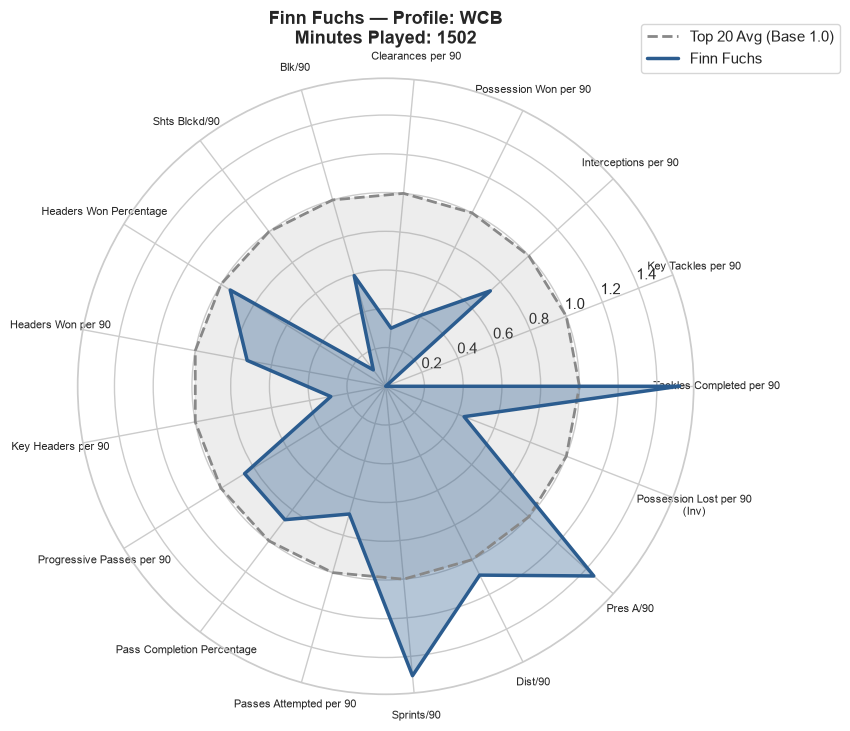

=== Profil: FB_WB (5 Spieler im Kader) ===


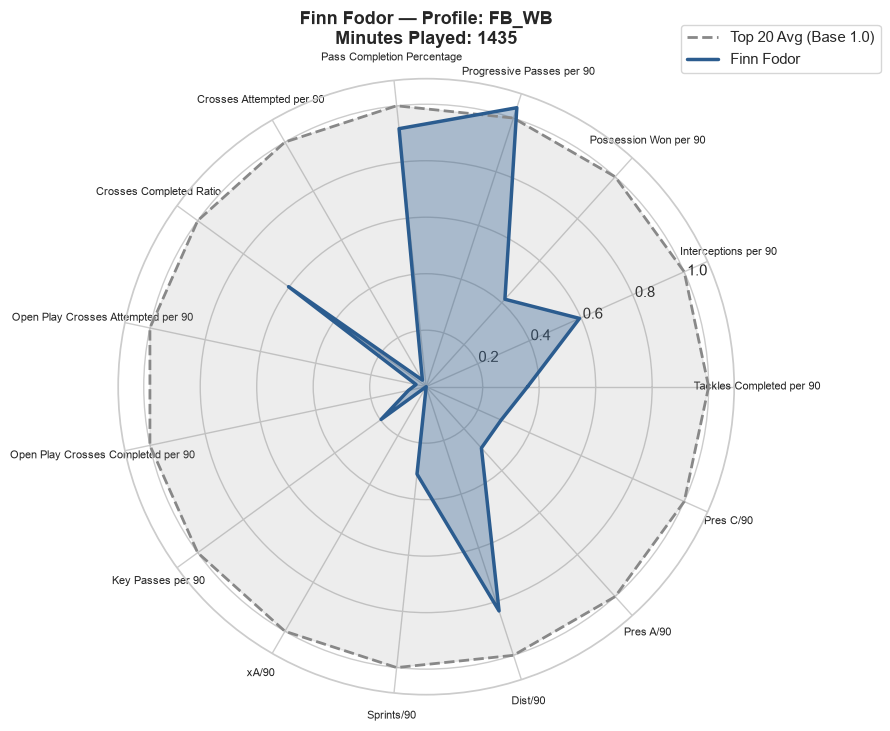

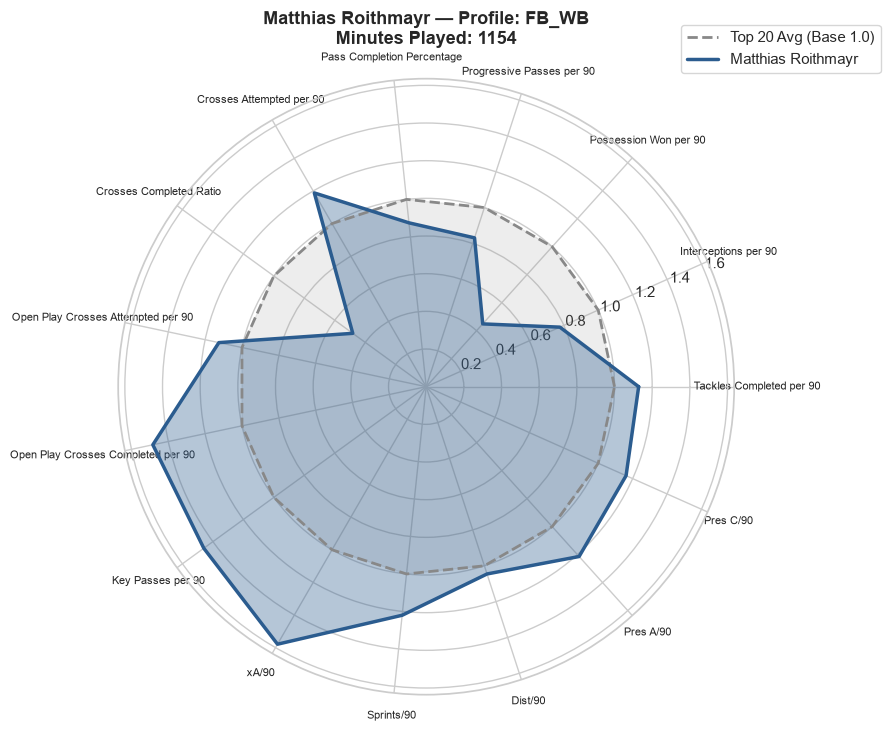

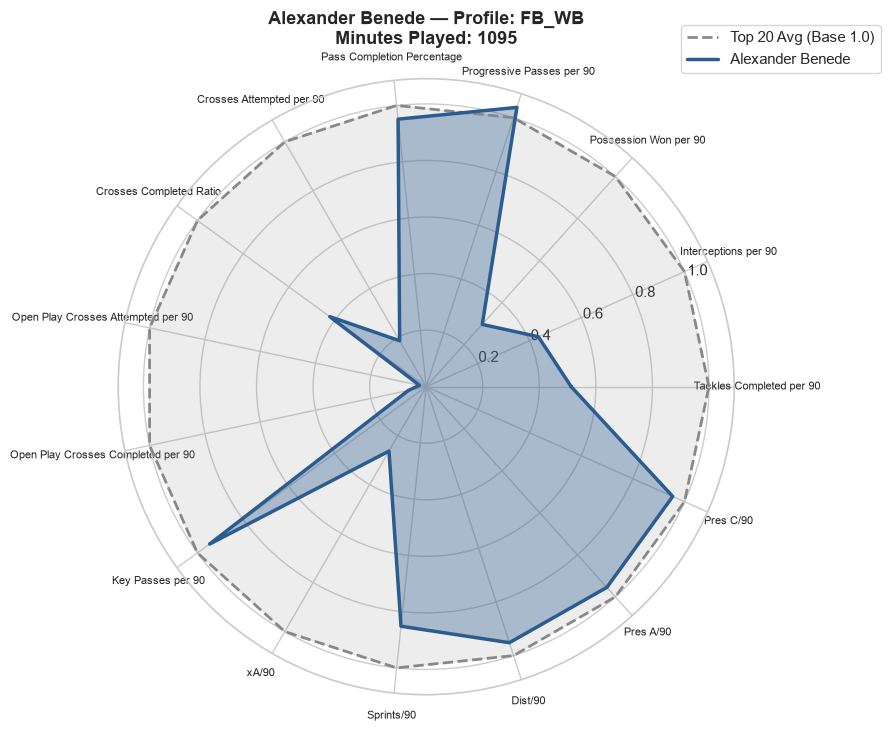

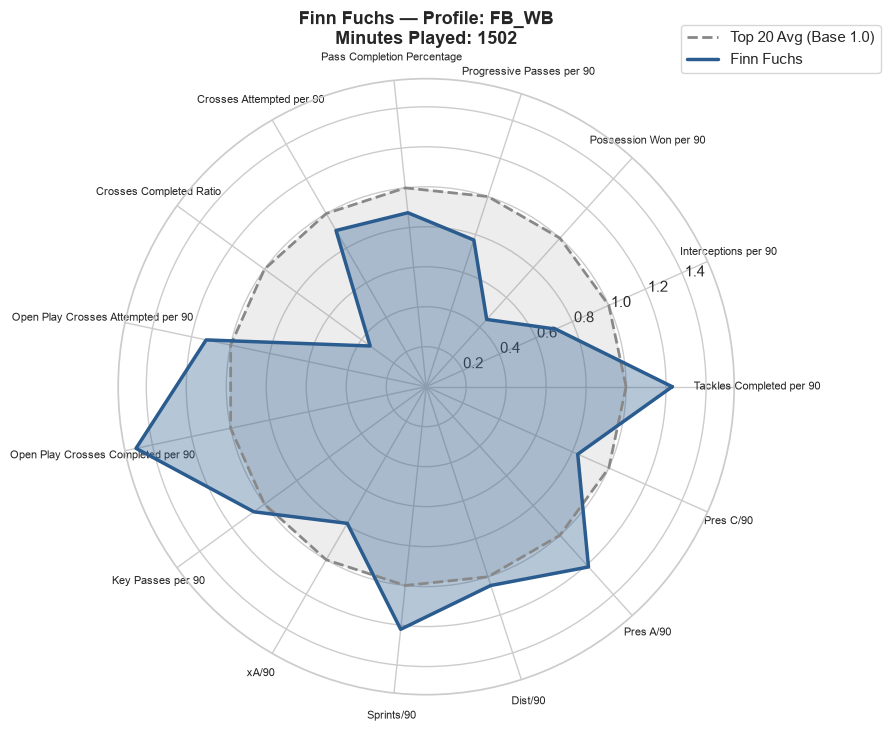

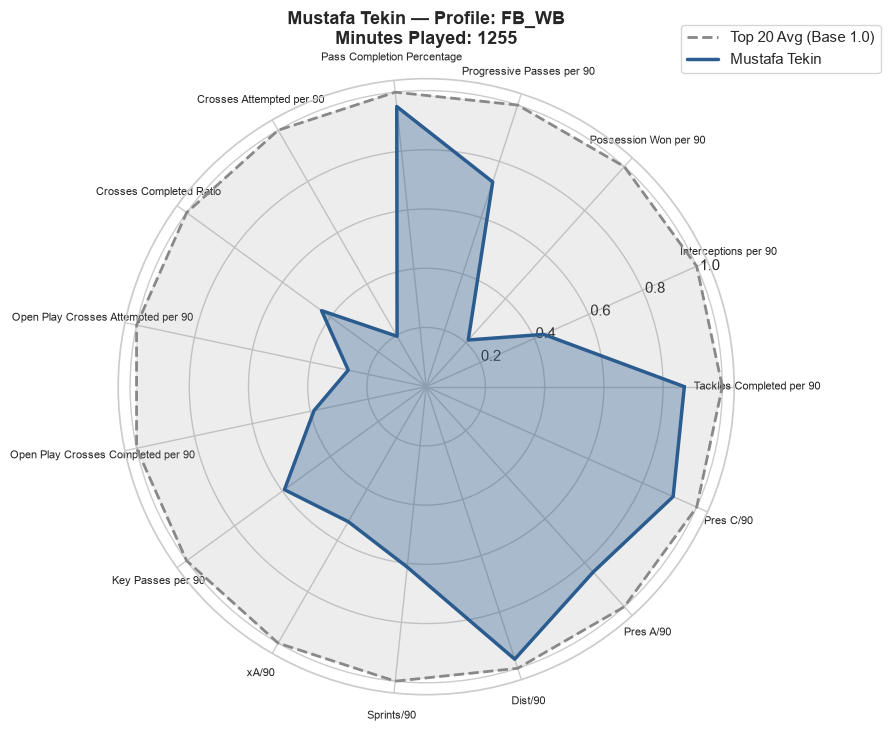

=== Profil: DLP_Pressing (4 Spieler im Kader) ===


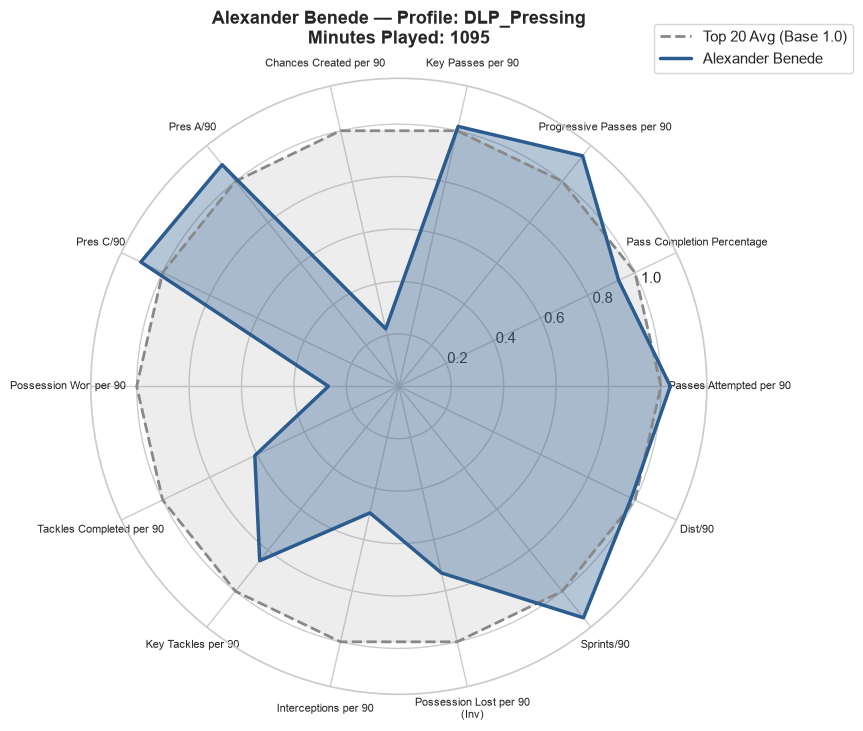

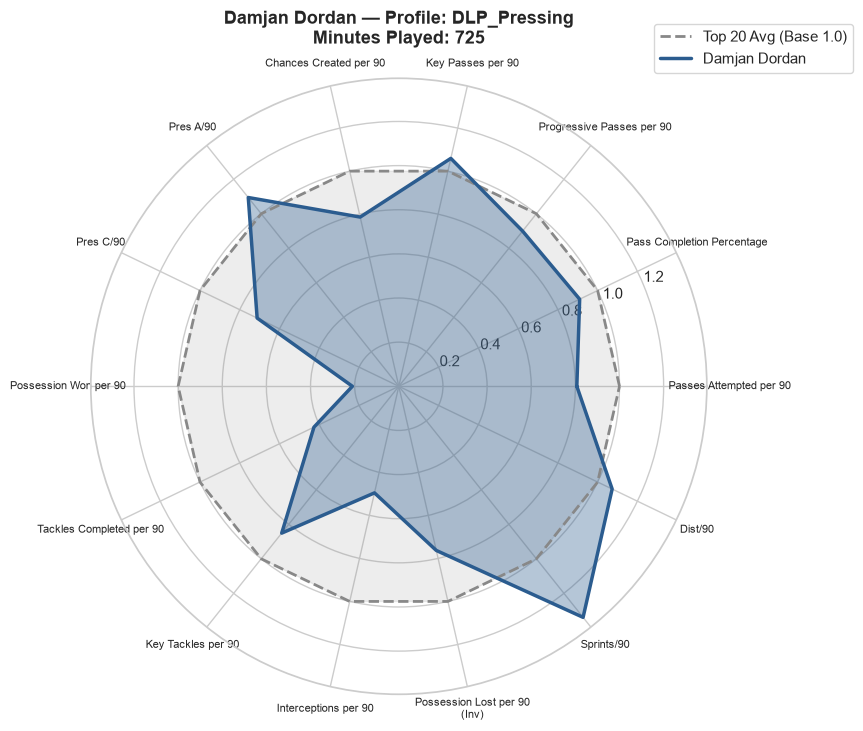

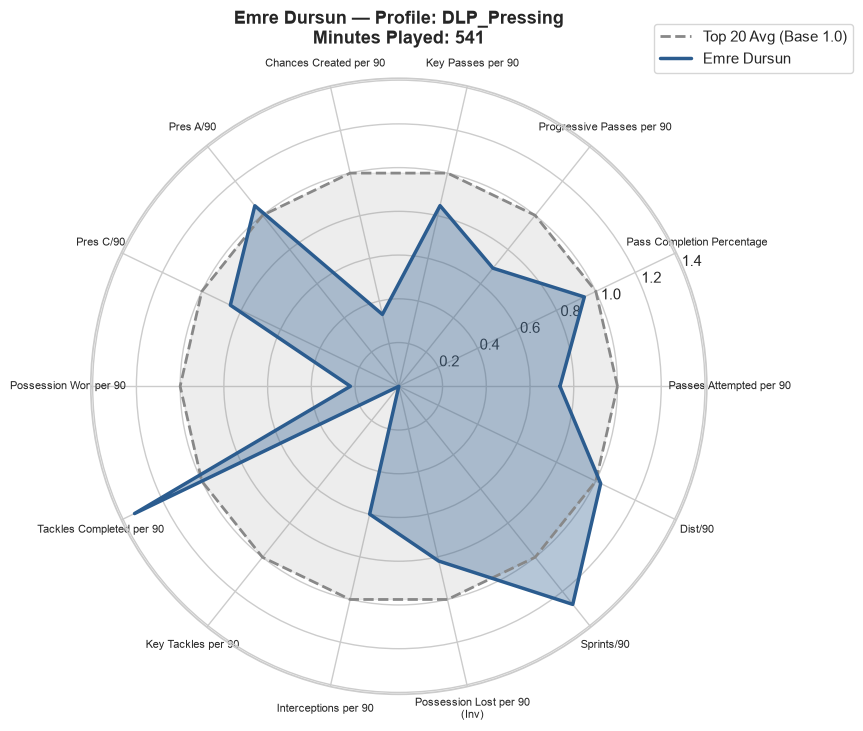

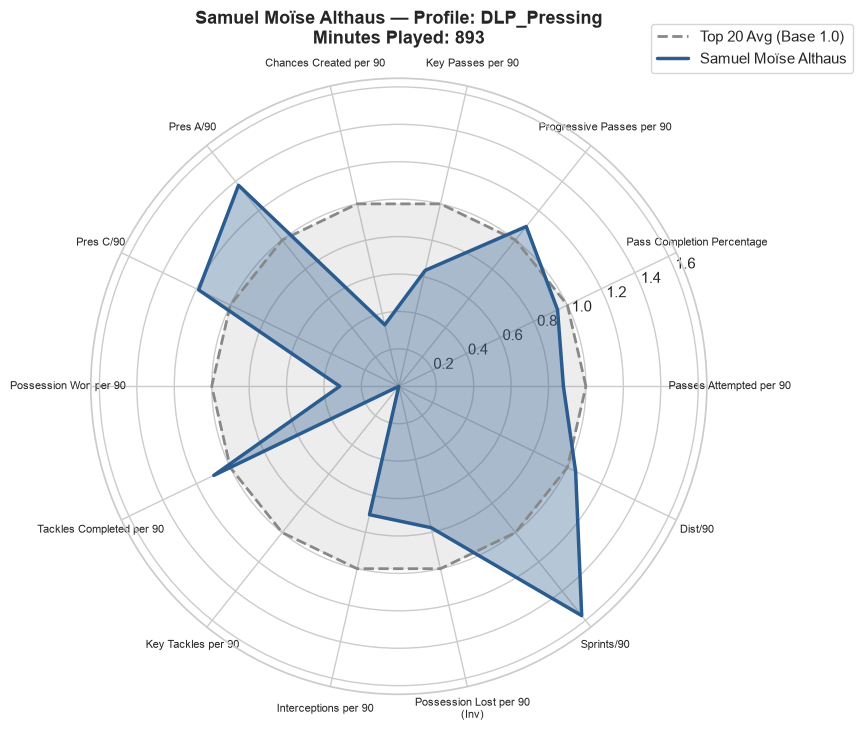

=== Profil: Channel_CM (5 Spieler im Kader) ===


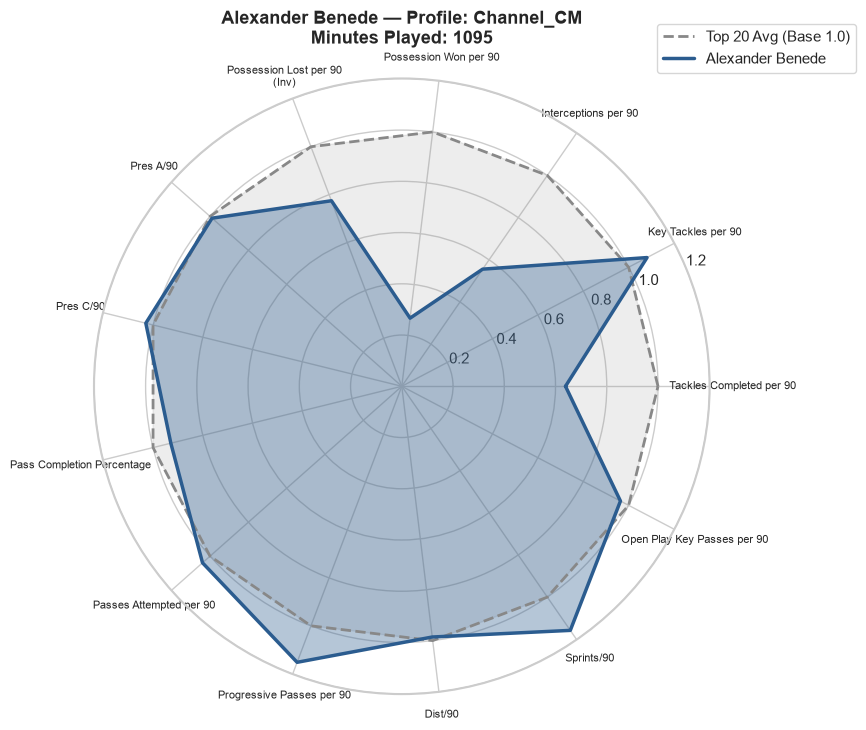

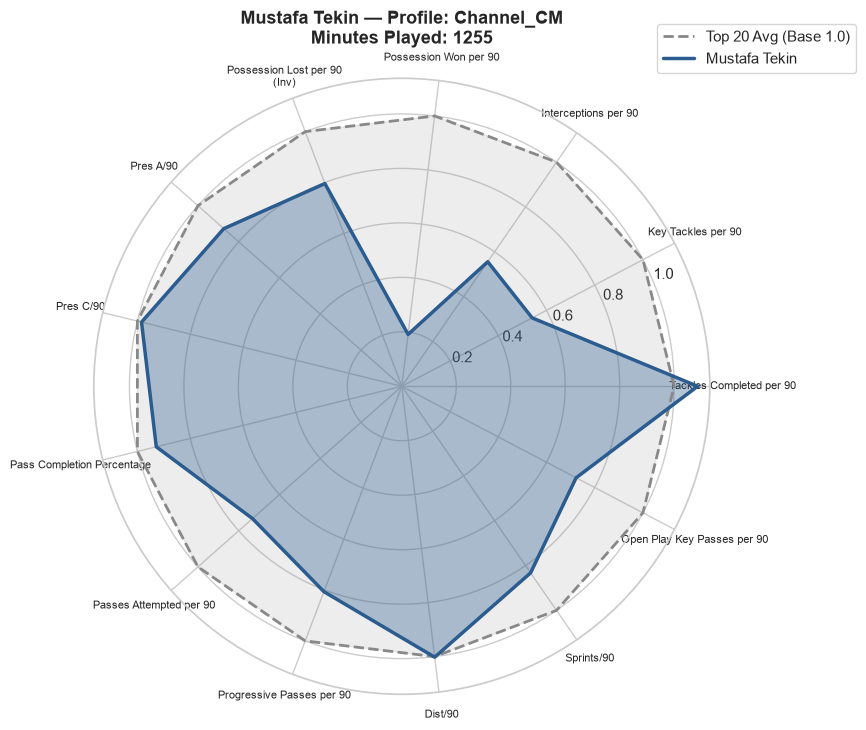

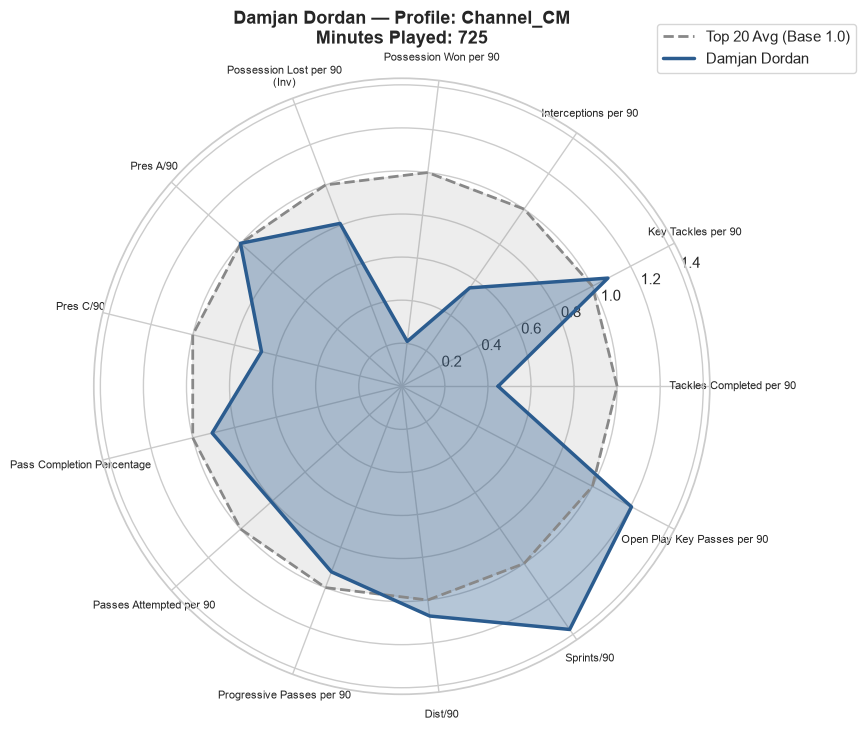

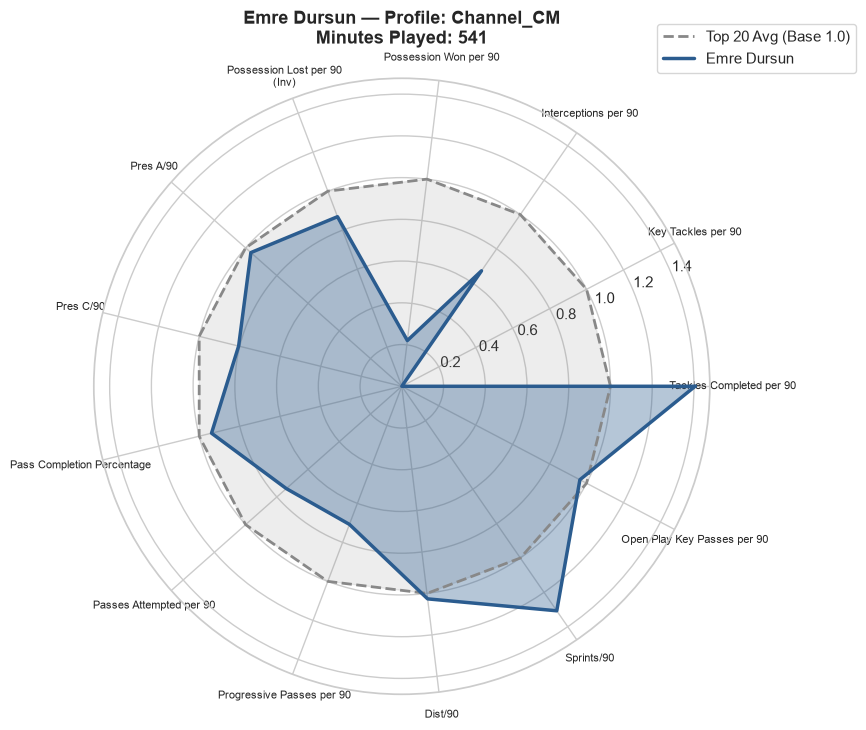

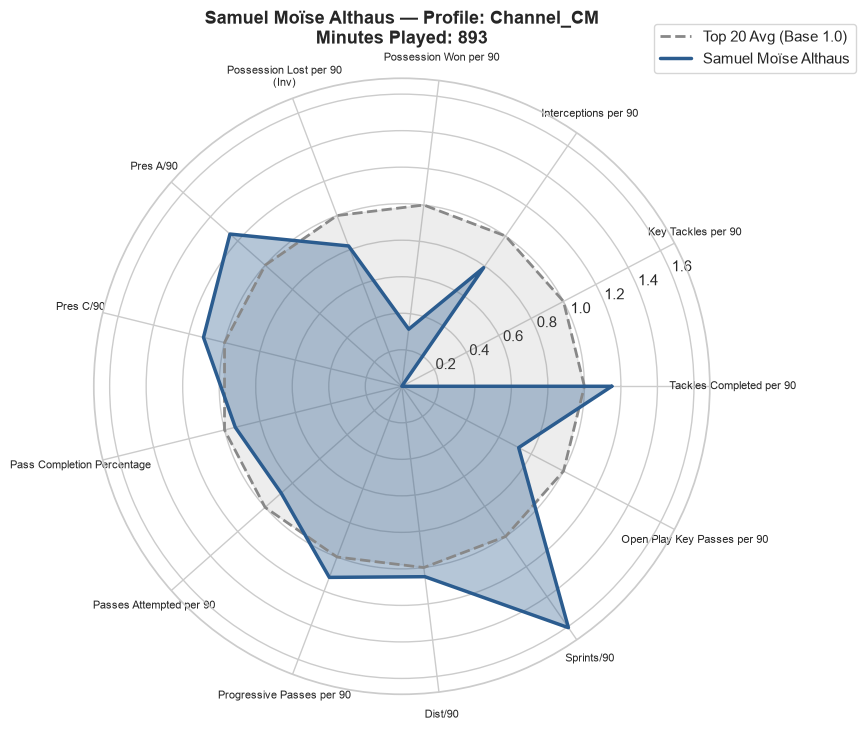

=== Profil: CM_AM_Playmaker (5 Spieler im Kader) ===


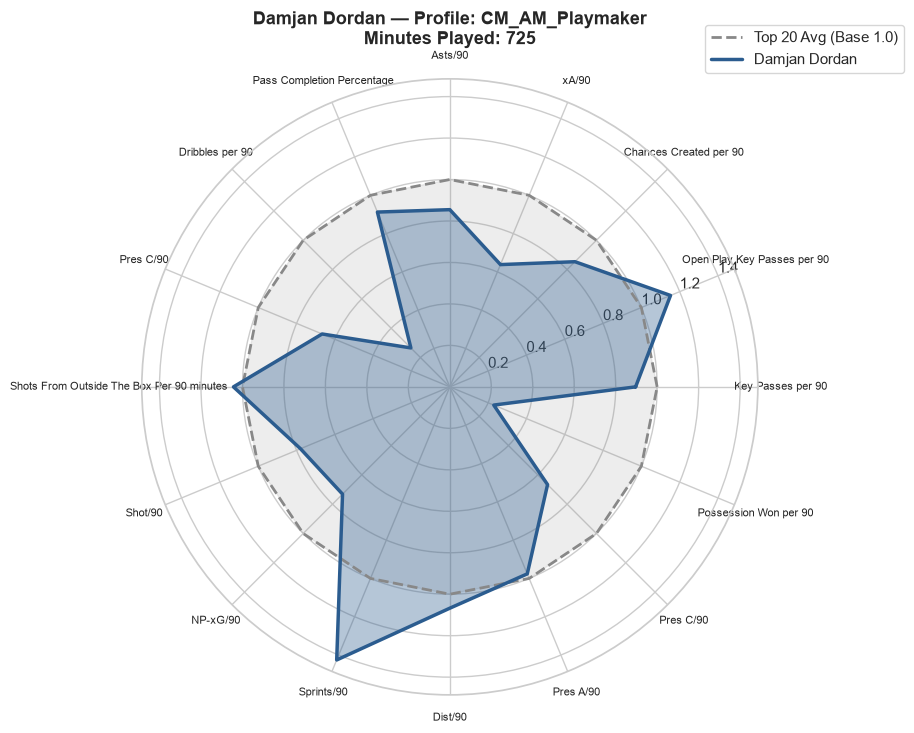

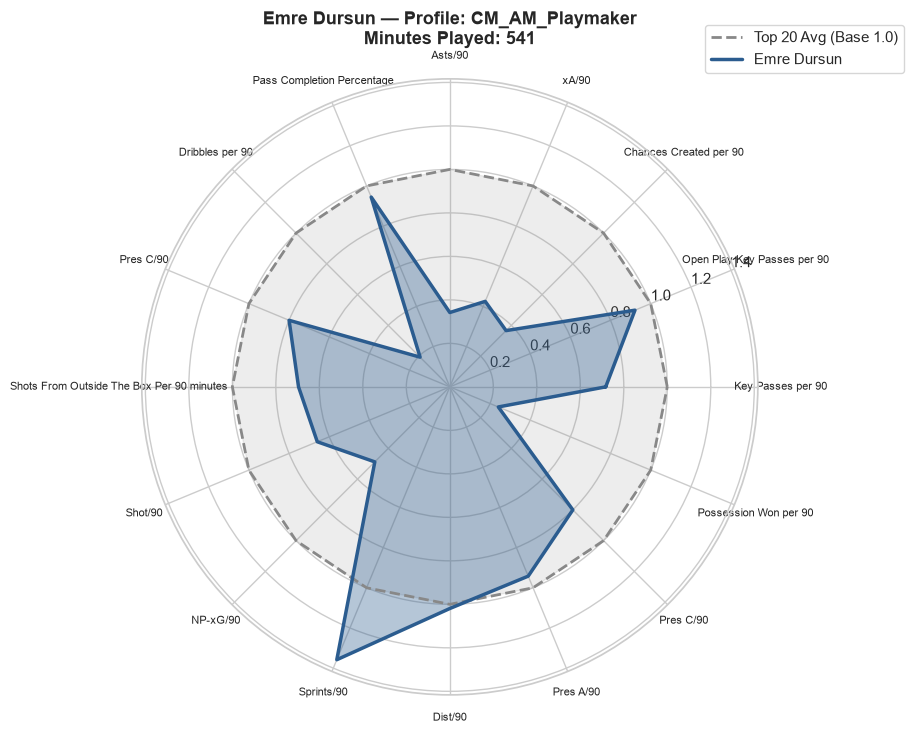

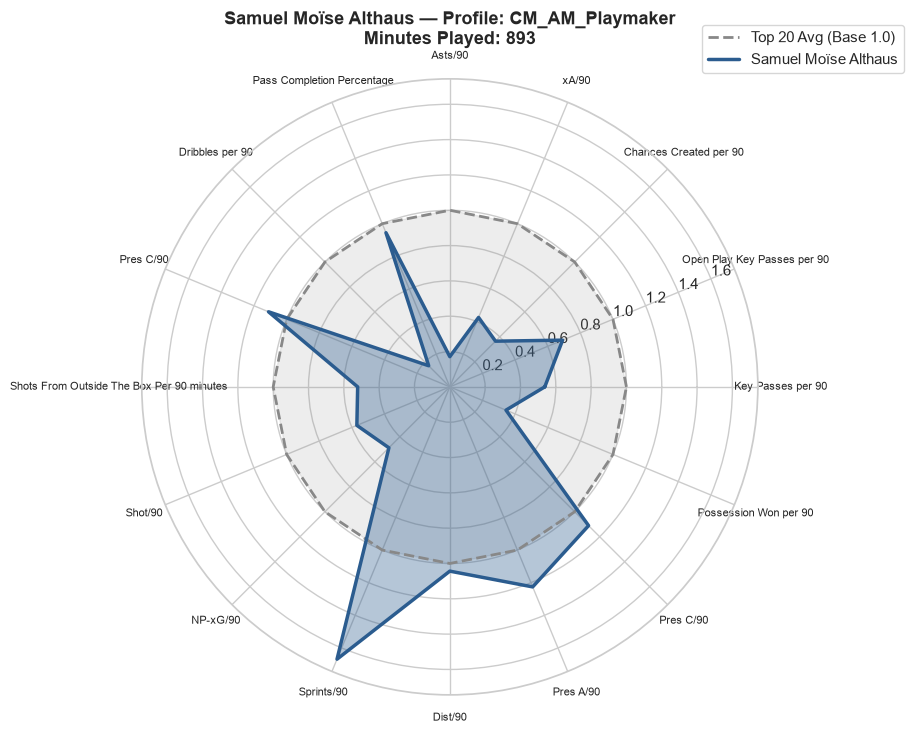

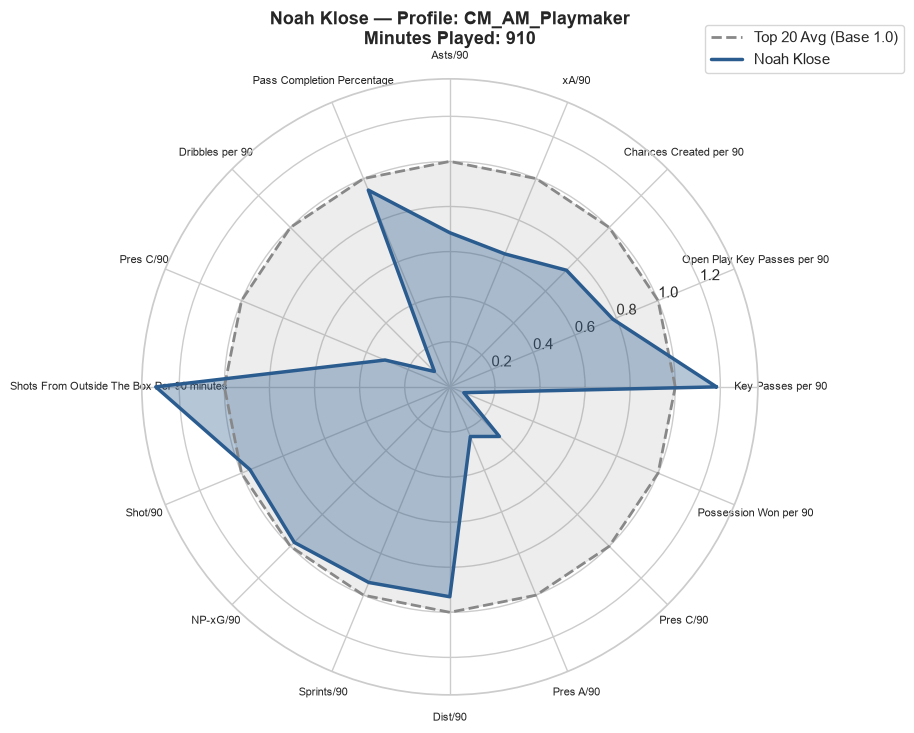

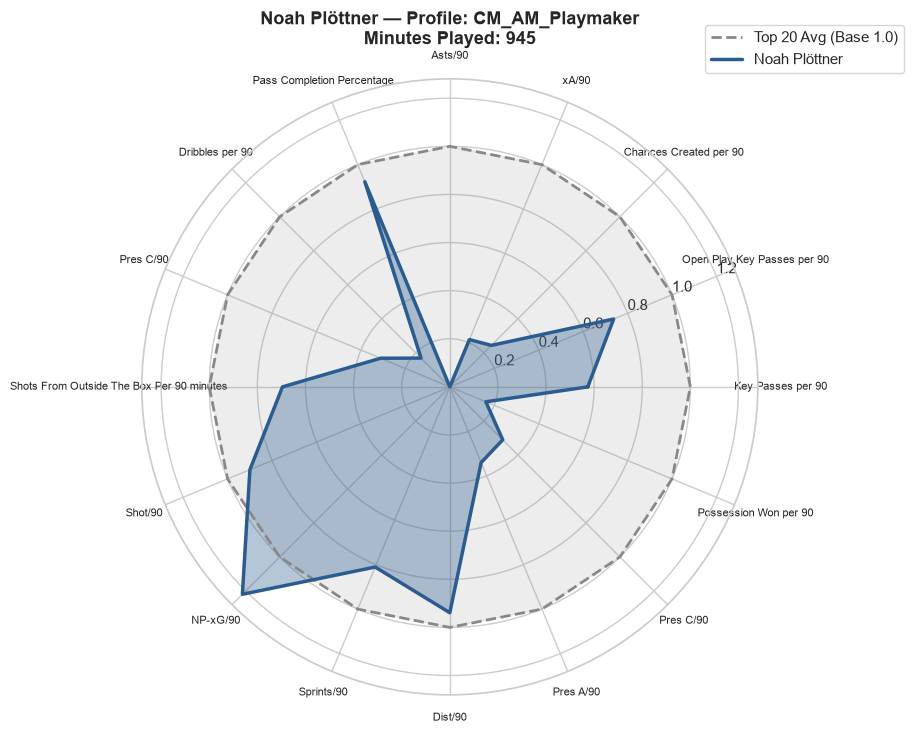

=== Profil: Target_FW (4 Spieler im Kader) ===


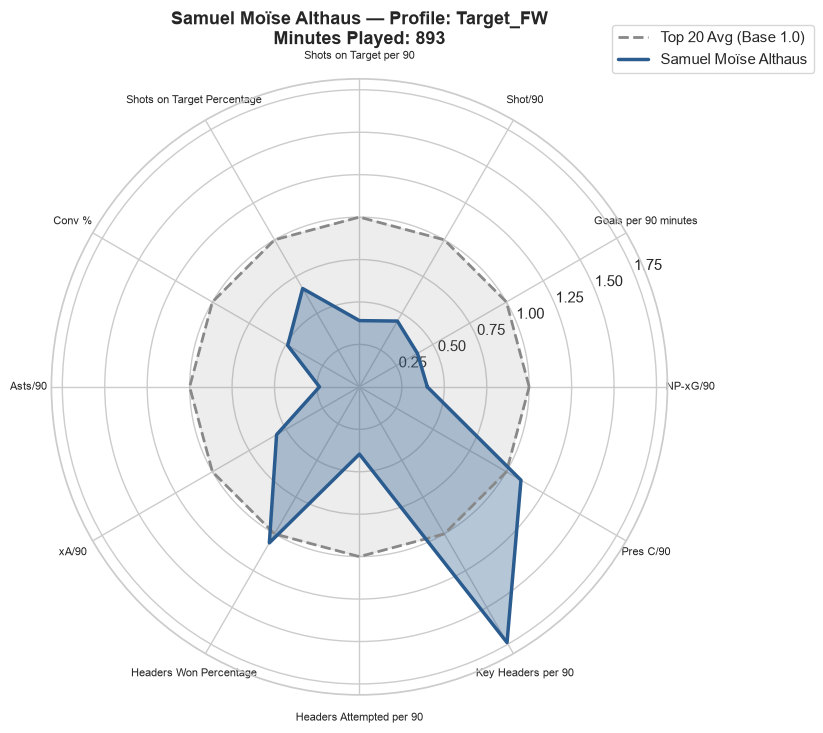

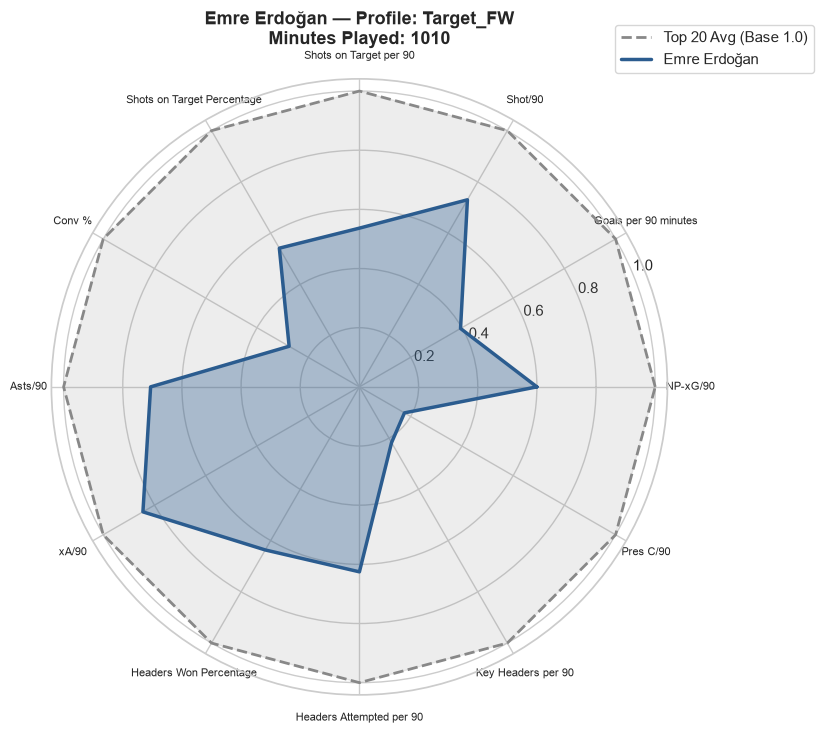

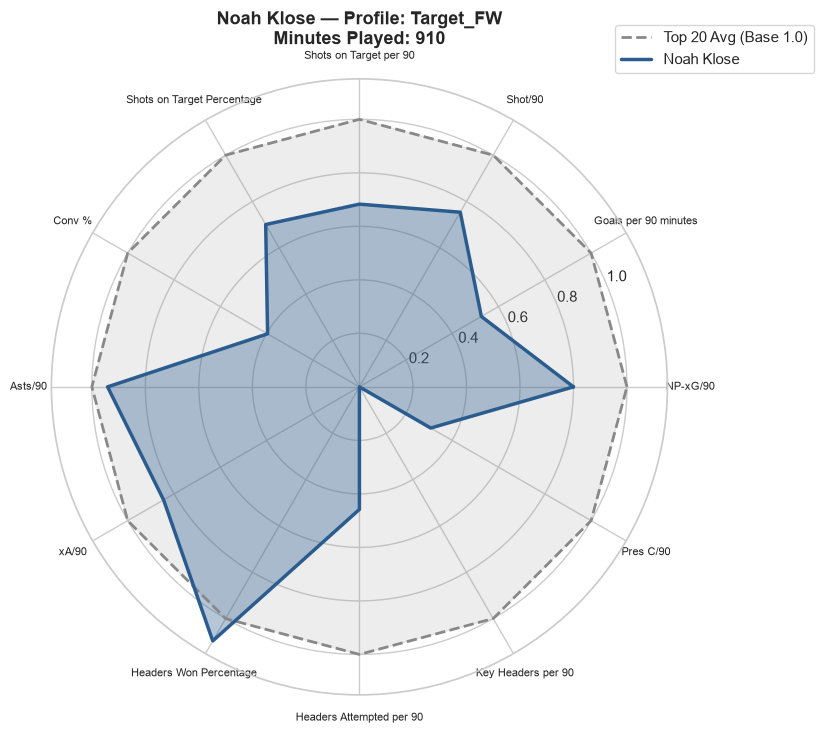

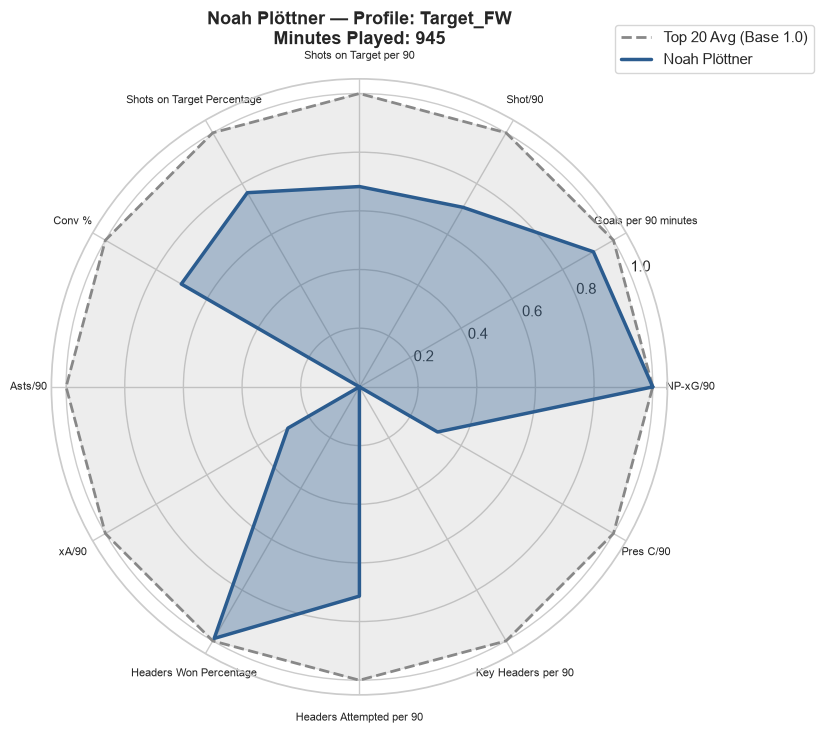

=== Profil: ST (4 Spieler im Kader) ===


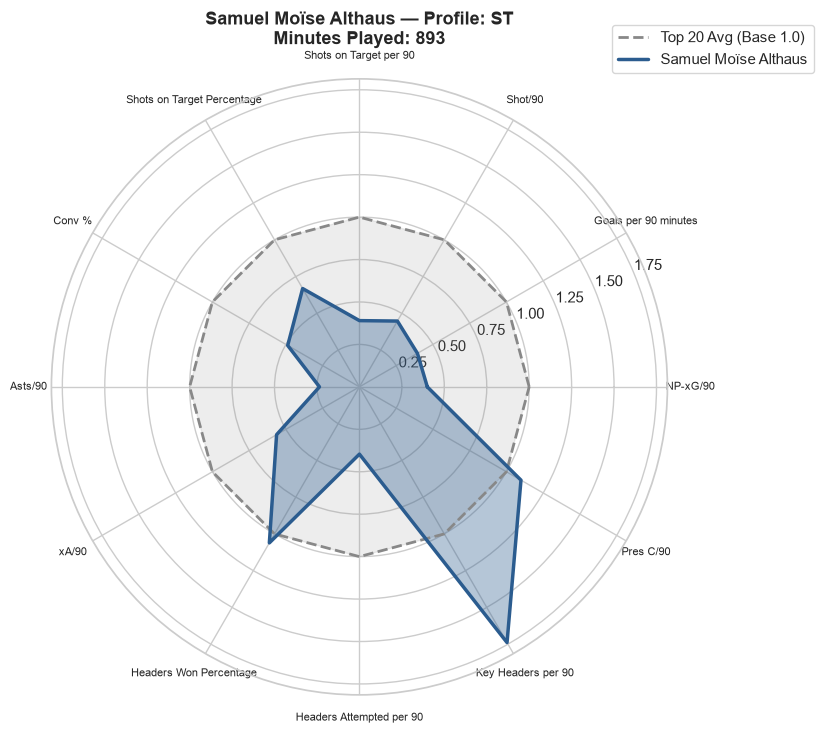

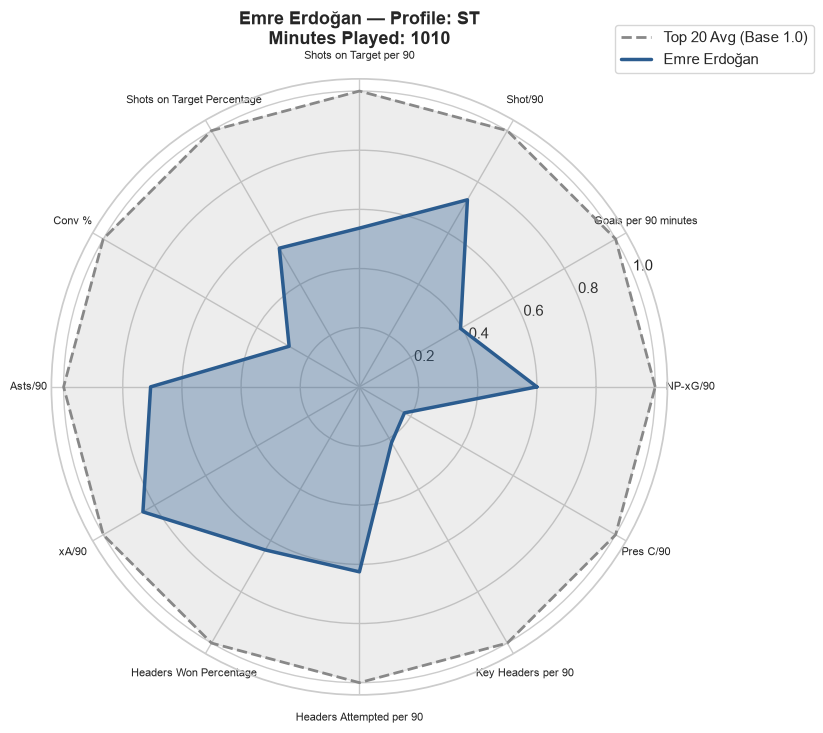

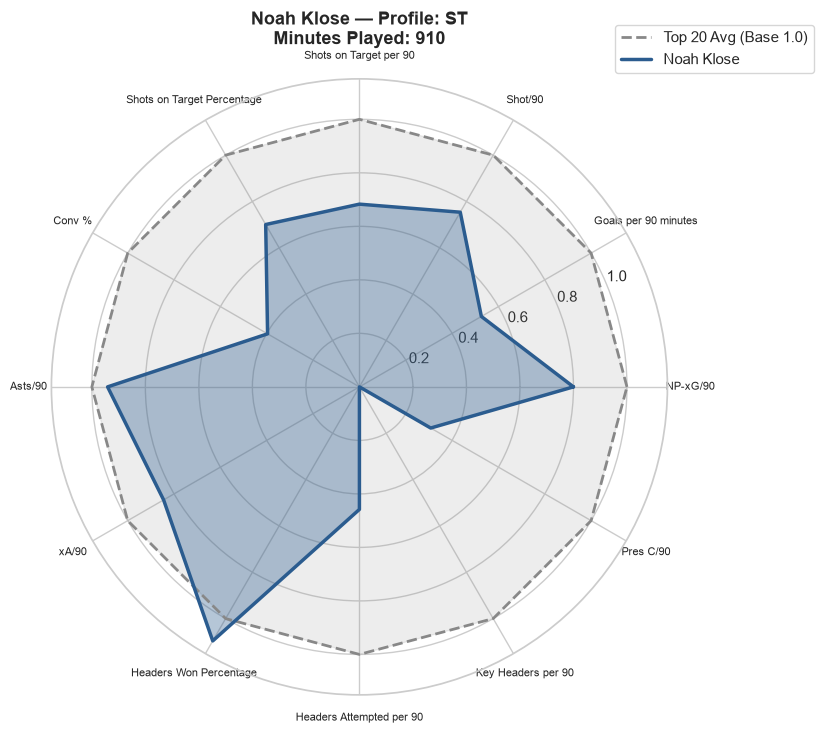

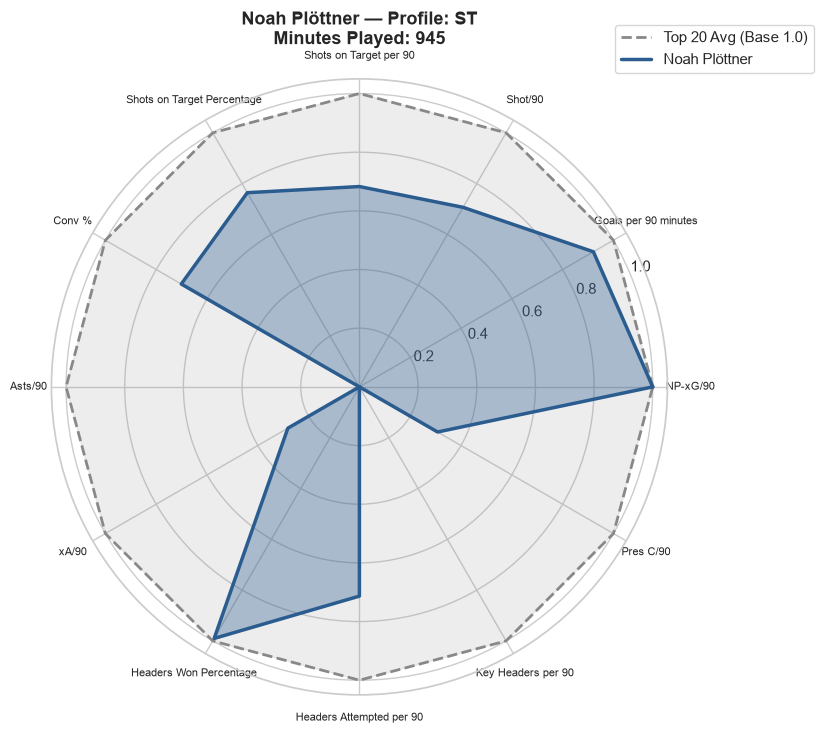

In [23]:
# 6. Visualisierung: Radar-Charts je Profil für eigene Spieler ausgeben
for role_name, role_cfg in pos_config.items():
    positions = role_cfg["positions"]
    sides = role_cfg["sides"]
    metrics = role_cfg["metrics"]

    squad_candidates = filter_players_by_position(df_own_norm, positions, sides)

    if squad_candidates.empty or role_name not in benchmarks:
        continue

    print(f"=== Profil: {role_name} ({len(squad_candidates)} Spieler im Kader) ===")

    for _, player_row in squad_candidates.iterrows():
        fig = plot_player_vs_benchmark_spider(
            player_row=player_row,
            role_name=role_name,
            role_metrics=metrics,
            role_benchmark=benchmarks[role_name],
            inverse_metrics=INVERSE_METRICS,
        )
        if fig:
            plt.show()

# Player Comparison

In [ ]:
fig = plot_two_players_vs_benchmark_spider(
    df_squad=df_own_norm,
    player_name_1="David Delgado",
    player_name_2="Borja Cortina",
    profile_key="WCB",
    config=config,
    benchmarks=benchmarks,
    inverse_metrics=INVERSE_METRICS,
)

if fig:
    plt.show()